# Связность запросов и статей: где fine-tuning получает прирост

Ноутбук построен как последовательный аргумент, а не как коллекция графиков:

1. **Структура данных:** 500 запросов покрывают лишь 79 из 793 статей.
2. **Структура giant component:** какие статьи образуют центральный тематический кластер.
3. **Поведение модели:** зависит ли прирост FT от того, встречалась ли статья в train.
4. **Перенос на test:** становится ли распределение предсказаний более концентрированным.

> Важно: граф на calibration использует ground truth и предназначен для диагностики. Его нельзя целиком использовать как OOF-признак — co-label-рёбра для каждого фолда должны строиться только по train-части. Геометрическое расстояние интерпретируется только на радиальной карте giant component; несвязанные компоненты не раскладываются в общее случайное «кольцо».

In [1]:
from __future__ import annotations

import json
import math
import re
from collections import Counter, defaultdict
from itertools import combinations
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from matplotlib.lines import Line2D
from matplotlib.patches import Circle, Patch, Rectangle, Wedge
from scipy.stats import spearmanr

sns.set_theme(style="whitegrid", context="notebook")
mpl.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 160,
    "axes.titleweight": "bold",
    "font.size": 10,
})

def find_project_root() -> Path:
    starts = [Path.cwd(), *Path.cwd().parents, Path.cwd() / "..", Path.cwd() / "../.."]
    for start in starts:
        candidate = start.resolve()
        if (candidate / "candidate_data/calibration.f").exists() and (candidate / "solution").exists():
            return candidate
    raise FileNotFoundError("Не найден корень проекта с candidate_data/ и solution/")

ROOT = find_project_root()
SOLUTION = ROOT / "solution"
DATA = ROOT / "candidate_data"

articles = pd.read_feather(DATA / "articles.f")
calibration = pd.read_feather(DATA / "calibration.f")
test = pd.read_feather(DATA / "test.f")
article_title = articles.set_index("article_id")["title"].fillna("").astype(str).to_dict()
gt = {
    int(qid): {int(x) for x in str(raw).split()}
    for qid, raw in zip(calibration["query_id"], calibration["ground_truth"])
}
labeled_articles = sorted(set().union(*gt.values()))
article_frequency = Counter(aid for relevant in gt.values() for aid in relevant)

print(f"ROOT: {ROOT}")
print(f"Статей в корпусе: {len(articles)}; размеченных статей: {len(labeled_articles)}; запросов: {len(calibration)}")

/home/ivan/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


ROOT: /home/ivan/Desktop/Avito_summer_2026/try_0
Статей в корпусе: 793; размеченных статей: 79; запросов: 500


/home/ivan/.local/lib/python3.12/site-packages/pandas/io/feather_format.py:178: FutureWarning: pyarrow.feather.read_table is deprecated as of 24.0.0. Use pyarrow.ipc.open_file() / RecordBatchFileReader instead. Feather V2 is the Arrow IPC file format.
  pa_table = feather.read_table(


In [2]:
def load_score_matrix(path: Path) -> dict[str, np.ndarray]:
    with np.load(path, allow_pickle=False) as data:
        return {
            "query_ids": data["query_ids"].astype(np.int64),
            "article_ids": data["article_ids"].astype(np.int64),
            "scores": data["scores"].astype(np.float32),
        }

def rankings(matrix: dict[str, np.ndarray], k: int = 10) -> dict[int, list[int]]:
    result = {}
    article_ids = matrix["article_ids"]
    for qid, row in zip(matrix["query_ids"], matrix["scores"]):
        order = np.lexsort((article_ids, -row))[:k]
        result[int(qid)] = article_ids[order].tolist()
    return result

def ap_at_10(predicted: list[int], relevant: set[int]) -> float:
    hits = 0
    total = 0.0
    for rank, aid in enumerate(predicted[:10], start=1):
        if aid in relevant:
            hits += 1
            total += hits / rank
    return total / min(len(relevant), 10) if relevant else 0.0

# Bipartite-граф содержит только статьи, которые хотя бы раз встретились в GT.
B = nx.Graph()
for qid, relevant in gt.items():
    qnode = ("q", qid)
    B.add_node(qnode, kind="query")
    for aid in relevant:
        anode = ("a", aid)
        B.add_node(anode, kind="article")
        B.add_edge(qnode, anode)

components = sorted(
    nx.connected_components(B),
    key=lambda nodes: sum(node[0] == "q" for node in nodes),
    reverse=True,
)
component_rows = []
for idx, nodes in enumerate(components, start=1):
    component_rows.append({
        "component": idx,
        "queries": sum(node[0] == "q" for node in nodes),
        "articles": sum(node[0] == "a" for node in nodes),
        "edges": B.subgraph(nodes).number_of_edges(),
    })
component_df = pd.DataFrame(component_rows)

summary = pd.DataFrame({
    "показатель": [
        "Запросов", "Статей корпуса", "Статей с GT", "Положительных связей",
        "Компонент", "Запросов в giant component", "Статей в giant component",
        "Singleton-статей", "Доля GT-связей у top-10 статей",
    ],
    "значение": [
        len(gt), len(articles), len(labeled_articles), B.number_of_edges(), len(components),
        component_df.iloc[0]["queries"], component_df.iloc[0]["articles"],
        sum(freq == 1 for freq in article_frequency.values()),
        f"{sum(v for _, v in article_frequency.most_common(10)) / B.number_of_edges():.1%}",
    ],
})
display(summary)

,показатель,значение
0,Запросов,500
1,Статей корпуса,793
2,Статей с GT,79
3,Положительных связей,761
4,Компонент,31
5,Запросов в giant component,453
6,Статей в giant component,32
7,Singleton-статей,40
8,Доля GT-связей у top-10 статей,65.4%


## 1. Профиль компонент связности

Левая панель показывает доминирование giant component. Правая увеличивает остальные компоненты, которые иначе визуально исчезают.

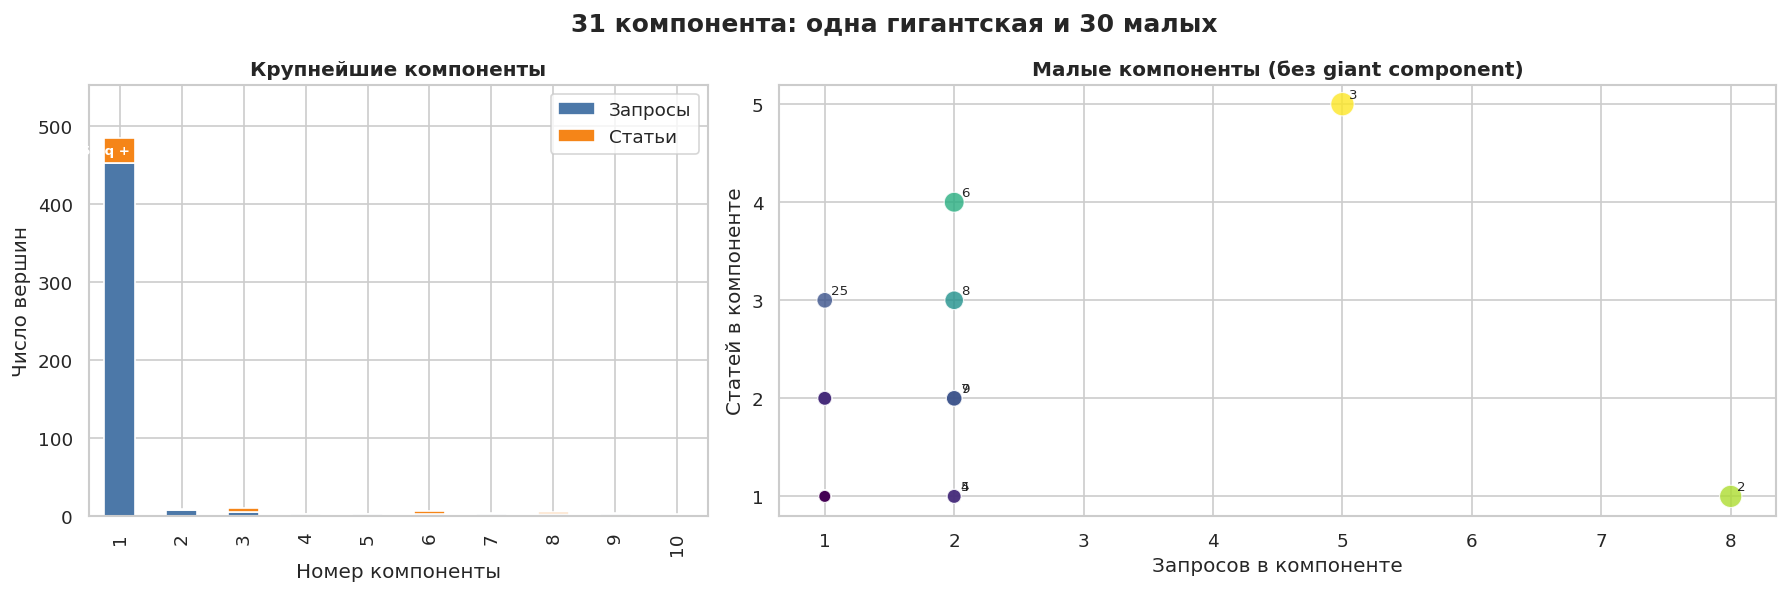

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={"width_ratios": [1.15, 1.85]})

first = component_df.head(10).set_index("component")[["queries", "articles"]]
first.plot(kind="bar", stacked=True, color=["#4C78A8", "#F58518"], ax=axes[0])
axes[0].set_title("Крупнейшие компоненты")
axes[0].set_xlabel("Номер компоненты")
axes[0].set_ylabel("Число вершин")
axes[0].legend(["Запросы", "Статьи"])
axes[0].set_ylim(0, first.iloc[0].sum() * 1.14)
axes[0].text(0, first.iloc[0].sum() - 8, f"{int(first.iloc[0]['queries'])} q + {int(first.iloc[0]['articles'])} a",
             ha="center", va="top", color="white", fontsize=8, fontweight="bold")

tail = component_df.iloc[1:].copy()
axes[1].scatter(tail["queries"], tail["articles"], s=35 + 18 * tail["edges"],
                c=tail["edges"], cmap="viridis", alpha=0.8, edgecolor="white", linewidth=0.7)
for row in tail.itertuples():
    if row.queries >= 2 or row.articles >= 3:
        axes[1].annotate(str(row.component), (row.queries, row.articles), xytext=(4, 4), textcoords="offset points", fontsize=8)
axes[1].set_title("Малые компоненты (без giant component)")
axes[1].set_xlabel("Запросов в компоненте")
axes[1].set_ylabel("Статей в компоненте")
axes[1].set_xticks(range(1, int(tail["queries"].max()) + 1))
axes[1].set_yticks(range(1, int(tail["articles"].max()) + 1))
fig.suptitle("31 компонента: одна гигантская и 30 малых", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

## 2. Poincaré-подобная карта giant component (почти гиперболическая с.к.)

Здесь показана только проекция **32 статей** главной компоненты. Корень `4219 — Покупателю` помещён в центр. Радиус имеет явный смысл: это кратчайшее число co-label-рёбер до `4219`. Для усиления периферии графовое расстояние отображается в диск формулой `r = tanh(0.55 · distance)` — это Poincaré-подобное, но не обучаемое гиперболическое вложение.

- цвет = тематическое сообщество, найденное greedy modularity;
- размер вершины = GT-частота статьи;
- толщина ребра = число запросов, где две статьи размечены вместе;
- чтобы карта читалась, показаны рёбра с весом ≥3 и сильнейшее ребро каждой статьи;
- цифры на самых сильных рёбрах — точное число совместных появлений.

Цвет FT здесь намеренно не используется: эта картинка отвечает только на вопрос о структуре разметки.

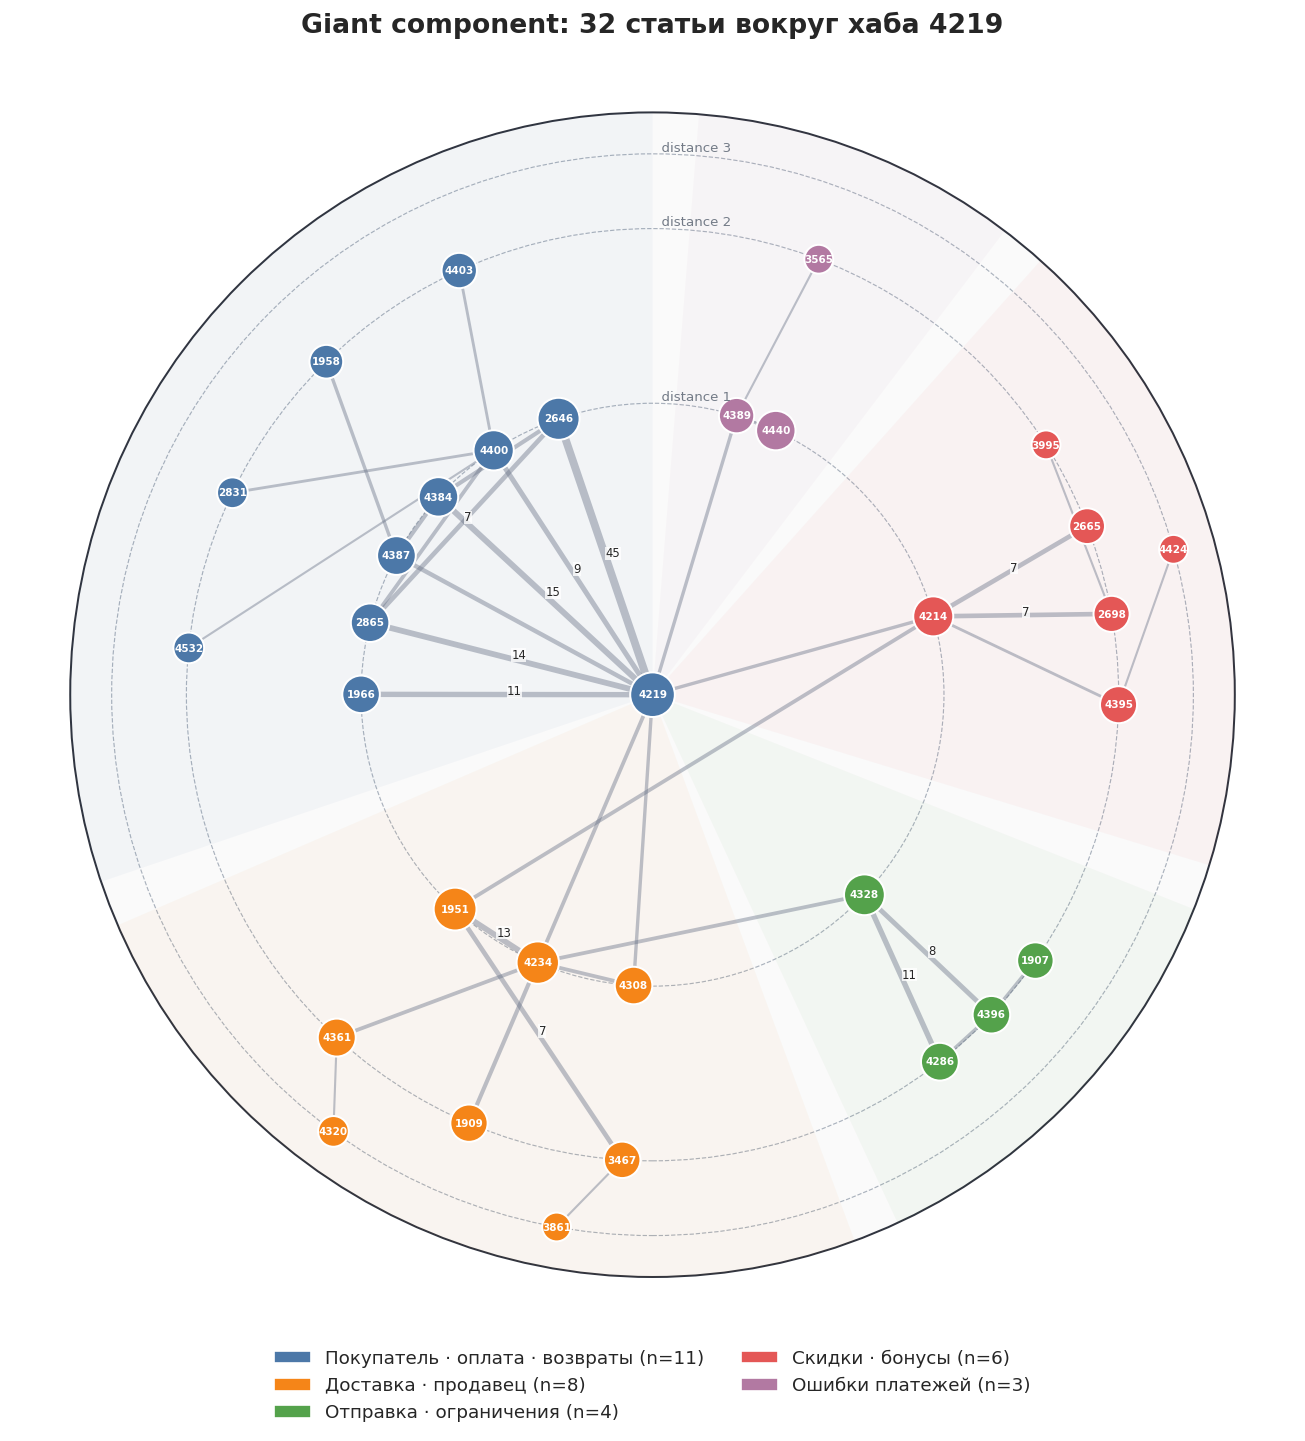

,community,article_id,title,GT frequency,distance from 4219
0,Покупатель · оплата · возвраты,4219,Покупателю,129,0
1,Покупатель · оплата · возвраты,2646,Оплата заказов с доставкой,57,1
2,Покупатель · оплата · возвраты,4400,Покупателю — отказаться от товара или вернуть его,33,1
3,Покупатель · оплата · возвраты,4384,Баланс для покупок,26,1
4,Покупатель · оплата · возвраты,4387,Всё про отмену заказа,21,1
5,Покупатель · оплата · возвраты,2865,Когда вернутся деньги за доставку,20,1
6,Покупатель · оплата · возвраты,1966,Когда вернутся деньги после отмены доставки в ...,15,1
7,Покупатель · оплата · возвраты,4403,Продавцу — товар не забирают или вернули,8,2
8,Покупатель · оплата · возвраты,1958,Продавец не отправляет заказ,5,2
9,Покупатель · оплата · возвраты,2831,Приехал повреждённый товар,2,2


In [4]:
# Article projection: ребро означает совместное появление двух статей в GT.
P = nx.Graph()
P.add_nodes_from(labeled_articles)
for relevant in gt.values():
    for left, right in combinations(sorted(relevant), 2):
        if P.has_edge(left, right):
            P[left][right]["weight"] += 1
        else:
            P.add_edge(left, right, weight=1)

giant_article_nodes = max(nx.connected_components(P), key=len)
G = P.subgraph(giant_article_nodes).copy()
root_article = 4219
distance_from_root = dict(nx.shortest_path_length(G, source=root_article))

communities = sorted(
    nx.community.greedy_modularity_communities(G, weight="weight"),
    key=lambda community: sum(article_frequency[aid] for aid in community),
    reverse=True,
)
theme_by_anchor = {
    4219: "Покупатель · оплата · возвраты",
    4234: "Доставка · продавец",
    4328: "Отправка · ограничения",
    4214: "Скидки · бонусы",
    4440: "Ошибки платежей",
}
community_themes = []
for community in communities:
    anchor = next((aid for aid in theme_by_anchor if aid in community), max(community, key=article_frequency.get))
    community_themes.append(theme_by_anchor.get(anchor, str(anchor)))
community_colors = ["#4C78A8", "#F58518", "#54A24B", "#E45756", "#B279A2"]
community_of = {aid: index for index, community in enumerate(communities) for aid in community}

# Угловые сектора разделяют сообщества; радиус задаётся только graph distance.
counts = [len(community - {root_article}) for community in communities]
gap = 0.08
usable_angle = 2 * math.pi - gap * len(communities)
position = {root_article: np.array([0.0, 0.0])}
sector_bounds = []
current_angle = math.pi / 2
for community_index, community in enumerate(communities):
    width = usable_angle * counts[community_index] / sum(counts)
    start, end = current_angle, current_angle + width
    sector_bounds.append((start, end))
    nodes = [aid for aid in community if aid != root_article]
    for distance in sorted({distance_from_root[aid] for aid in nodes}):
        layer = sorted(
            [aid for aid in nodes if distance_from_root[aid] == distance],
            key=lambda aid: (-article_frequency[aid], aid),
        )
        margin = min(0.08, width * 0.12)
        angles = (
            np.linspace(start + margin, end - margin, len(layer) + 2)[1:-1]
            if len(layer) > 1 else np.array([(start + end) / 2])
        )
        radius = np.tanh(0.55 * distance)
        for aid, angle in zip(layer, angles):
            position[aid] = radius * np.array([math.cos(angle), math.sin(angle)])
    current_angle = end + gap

# Оставляем сильные рёбра и сильнейшее ребро каждой статьи.
display_edges = set()
for left, right, data in G.edges(data=True):
    if data["weight"] >= 3:
        display_edges.add(tuple(sorted((left, right))))
for aid in G.nodes():
    incident = list(G.edges(aid, data=True))
    if incident:
        left, right, _ = max(incident, key=lambda edge: edge[2]["weight"])
        display_edges.add(tuple(sorted((left, right))))
display_edges = list(display_edges)
display_weights = [G[left][right]["weight"] for left, right in display_edges]

fig, ax = plt.subplots(figsize=(12, 12))
ax.add_patch(Circle((0, 0), 1, facecolor="#FAFAFA", edgecolor="#30343F", linewidth=1.2))
for distance in [1, 2, 3]:
    radius = np.tanh(0.55 * distance)
    ax.add_patch(Circle((0, 0), radius, fill=False, edgecolor="#AAB2BD", linestyle="--", linewidth=0.7))
    ax.text(0, radius, f"  distance {distance}", fontsize=8, va="bottom", color="#737B87")
for community_index, (start, end) in enumerate(sector_bounds):
    ax.add_patch(Wedge(
        (0, 0), 1, np.degrees(start), np.degrees(end),
        facecolor=community_colors[community_index], alpha=0.045, edgecolor="none",
    ))
nx.draw_networkx_edges(
    G, position, edgelist=display_edges, ax=ax, edge_color="#667085", alpha=0.42,
    width=[0.5 + 1.1 * np.log1p(weight) for weight in display_weights],
)
for community_index, community in enumerate(communities):
    nodes = list(community)
    nx.draw_networkx_nodes(
        G, position, nodelist=nodes, ax=ax,
        node_size=[230 + 100 * np.log1p(article_frequency[aid]) for aid in nodes],
        node_color=community_colors[community_index], edgecolors="white", linewidths=1.2,
    )
nx.draw_networkx_labels(
    G, position, labels={aid: str(aid) for aid in G.nodes()},
    font_size=6.2, font_color="white", font_weight="bold", ax=ax,
)
for left, right in sorted(display_edges, key=lambda edge: G[edge[0]][edge[1]]["weight"], reverse=True)[:12]:
    x = (position[left][0] + position[right][0]) / 2
    y = (position[left][1] + position[right][1]) / 2
    ax.text(x, y, str(G[left][right]["weight"]), fontsize=7,
            bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.78, "pad": 0.15})
legend_handles = [
    Patch(facecolor=community_colors[index], label=f"{community_themes[index]} (n={len(community)})")
    for index, community in enumerate(communities)
]
ax.legend(handles=legend_handles, loc="lower center", bbox_to_anchor=(0.5, -0.07), ncol=2, frameon=False)
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.12, 1.12)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title("Giant component: 32 статьи вокруг хаба 4219", fontsize=16)
plt.tight_layout()
plt.show()

community_table = pd.DataFrame([
    {
        "community": community_themes[community_of[aid]],
        "article_id": aid,
        "title": article_title[aid],
        "GT frequency": article_frequency[aid],
        "distance from 4219": distance_from_root[aid],
    }
    for aid in sorted(G.nodes(), key=lambda aid: (community_of[aid], -article_frequency[aid], aid))
])
display(community_table)

## 3. Co-label матрица: точные связи без геометрии

Радиальная карта отвечает на вопрос «как устроен центр», но для точных пар лучше матрица. Строки и столбцы отсортированы сначала по сообществу, затем по частоте. Чёрные границы разделяют пять сообществ. Число в клетке показывается для связей с весом ≥3.

Например, самая сильная связь `4219 ↔ 2646` встречается в 45 запросах. Отсутствие связи означает только «статьи не были размечены вместе», а не семантическую несхожесть.

Белые клетки — **0 совместных запросов**; цвет начинается строго с веса 1. Серо-голубой фон подписей осей и знак `•` отмечают статьи с **GT-frequency = 1** во всей calibration. Таких статей 40 из 79, но в показанную giant component входят только четыре; остальные находятся в малых компонентах.

**Важно для протокола:** рисунок 3 описывает все 500 calibration-запросов, включая отложенные 100. Его нельзя напрямую использовать как источник обучающих фичей. Защищённая версия фичи в разделе 8 строит co-label-граф только по 400 dev-запросам.

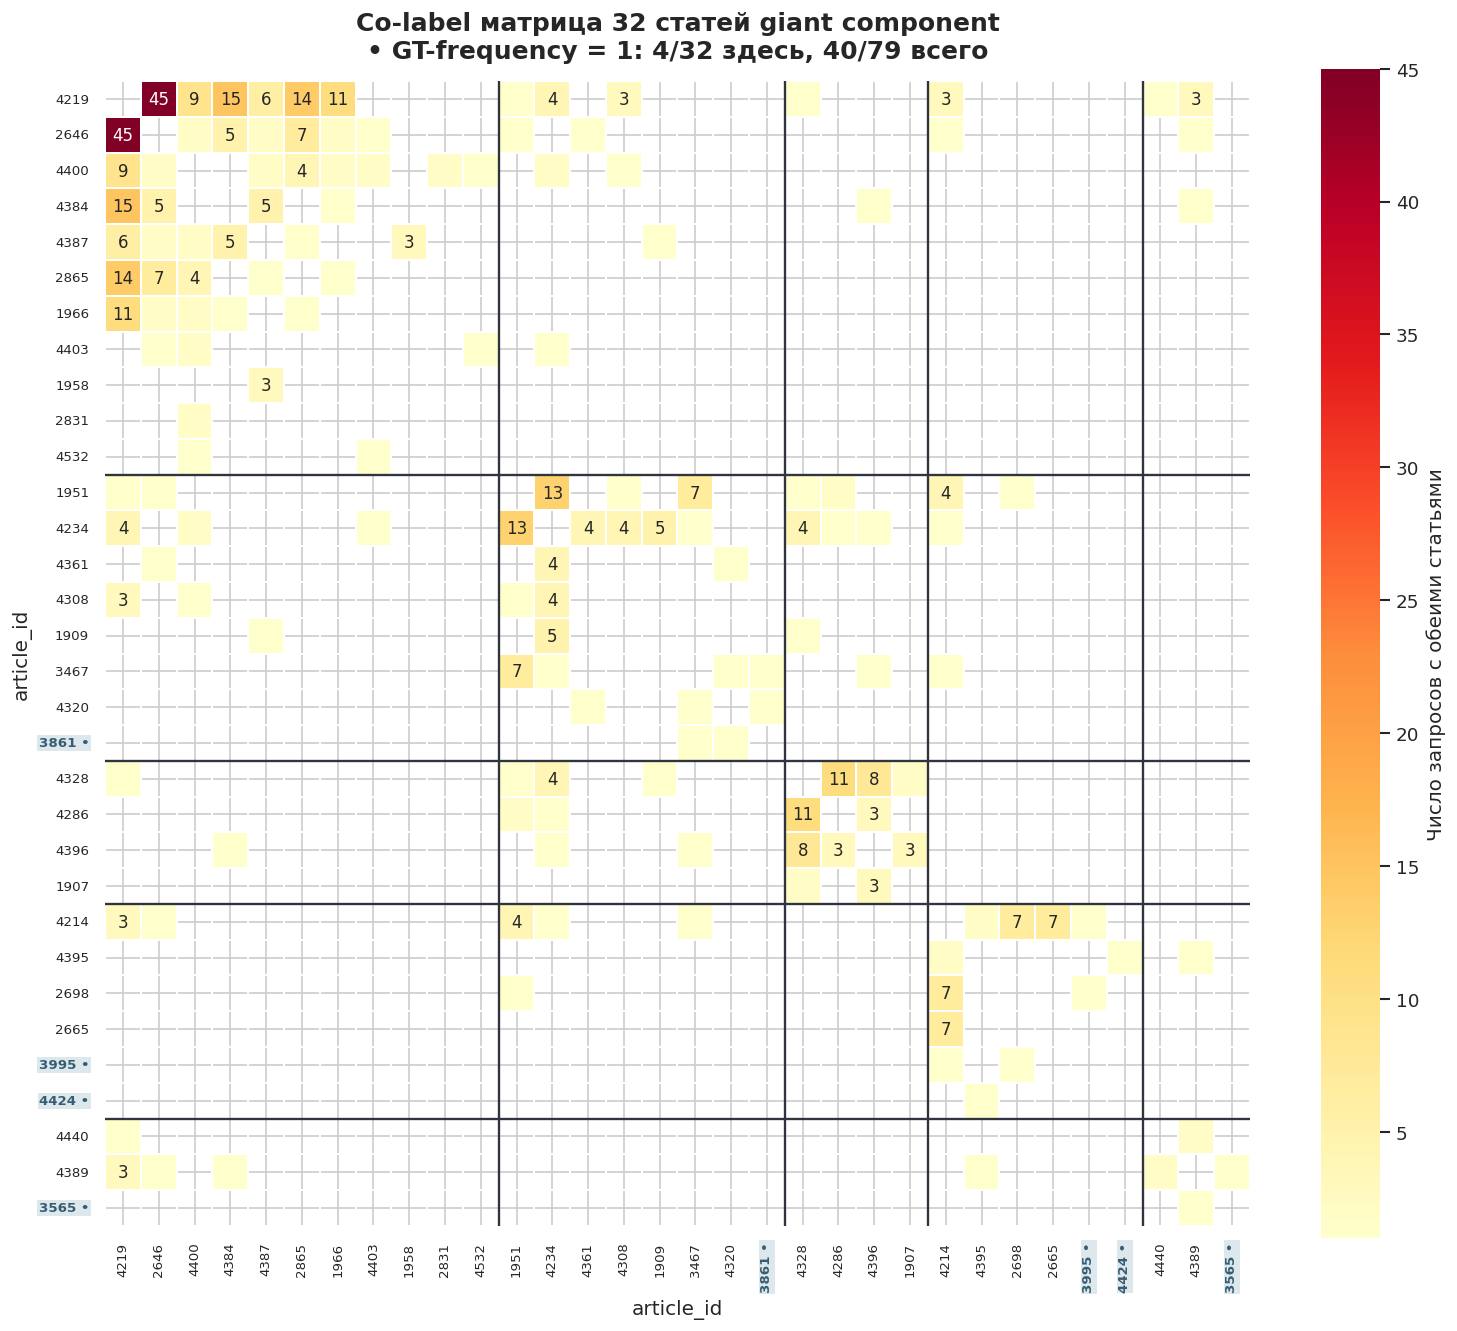

In [5]:
zs_cal = load_score_matrix(SOLUTION / "artifacts_rr_bge_zs_c40/scores/reranker/calibration.npz")
ft_cal = load_score_matrix(SOLUTION / "artifacts_rr_bge_ft_labeled/scores/reranker/calibration.npz")
zs_rank = rankings(zs_cal, 10)
ft_rank = rankings(ft_cal, 10)

with open(SOLUTION / "artifacts_rr_bge_ft_labeled/splits/folds.json", encoding="utf-8") as file:
    split_data = json.load(file)
dev_ids = {int(qid) for qid in split_data["dev"]}
fold_of = {int(qid): int(fold) for qid, fold in split_data["fold_of"].items()}

matrix_order = [
    aid
    for community in communities
    for aid in sorted(community, key=lambda aid: (-article_frequency[aid], aid))
]
co_label_matrix = np.zeros((len(matrix_order), len(matrix_order)), dtype=int)
for row, left in enumerate(matrix_order):
    for column, right in enumerate(matrix_order):
        if G.has_edge(left, right):
            co_label_matrix[row, column] = G[left][right]["weight"]
annotations = np.where(co_label_matrix >= 3, co_label_matrix.astype(str), "")
zero_mask = co_label_matrix == 0
singleton_article_ids = {aid for aid, frequency in article_frequency.items() if frequency == 1}
singleton_positions = [index for index, aid in enumerate(matrix_order) if aid in singleton_article_ids]
matrix_labels = [f"{aid} •" if aid in singleton_article_ids else str(aid) for aid in matrix_order]

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(
    co_label_matrix, ax=ax, mask=zero_mask, cmap="YlOrRd", vmin=1,
    vmax=int(co_label_matrix.max()), square=True, linewidths=0.25, linecolor="white",
    xticklabels=matrix_labels, yticklabels=matrix_labels, annot=annotations, fmt="",
    cbar_kws={"label": "Число запросов с обеими статьями"},
)
ax.set_facecolor("white")
boundary = 0
for community in communities[:-1]:
    boundary += len(community)
    ax.axhline(boundary, color="#30343F", linewidth=1.4)
    ax.axvline(boundary, color="#30343F", linewidth=1.4)
ax.tick_params(axis="x", rotation=90, labelsize=8)
ax.tick_params(axis="y", rotation=0, labelsize=8)
for index in singleton_positions:
    for tick_label in (ax.get_xticklabels()[index], ax.get_yticklabels()[index]):
        tick_label.set_color("#385D73")
        tick_label.set_fontweight("bold")
        tick_label.set_bbox({
            "facecolor": "#DCE7ED", "edgecolor": "none", "alpha": 0.95, "pad": 1.0
        })
ax.set_xlabel("article_id")
ax.set_ylabel("article_id")
ax.set_title(
    f"Co-label матрица 32 статей giant component\n"
    f"• GT-frequency = 1: {len(singleton_positions)}/32 здесь, {len(singleton_article_ids)}/79 всего",
    fontsize=15, pad=14,
)
plt.tight_layout()
plt.show()

Матрица подтверждает две вещи, которые дальше станут основой признаков:

1. **Связи редкие, но концентрированные.** Тёмных клеток мало, и почти весь вес лежит в блоке хаба `4219↔2646` (45 совместных запросов) и внутри блочной диагонали сообществ: статьи почти не размечаются вместе через границу темы.
2. **Хвост одиночек.** 40 из 79 размеченных статей встречаются в GT ровно один раз (в giant component таких 4 из 32 — подсвечены на осях). Для такой статьи co-label окрестность — одна-две соседки: сигнал «статья идёт в паре с X» либо очень точный, либо отсутствует вовсе, промежуточных случаев почти нет.

Практическое следствие: co-label вес пары — сильный кандидат в признаки ранжирования (точный там, где есть), но ему нужен fallback, не зависящий от разметки (HTML-ссылки, dense-похожесть), иначе 714 статей вне разметки — слепая зона.

## 4. Head–tail профиль разметки

Граф визуально подчёркивает хабы, но степень перекоса лучше читается на ранговом графике частот и кумулятивной доле положительных связей.

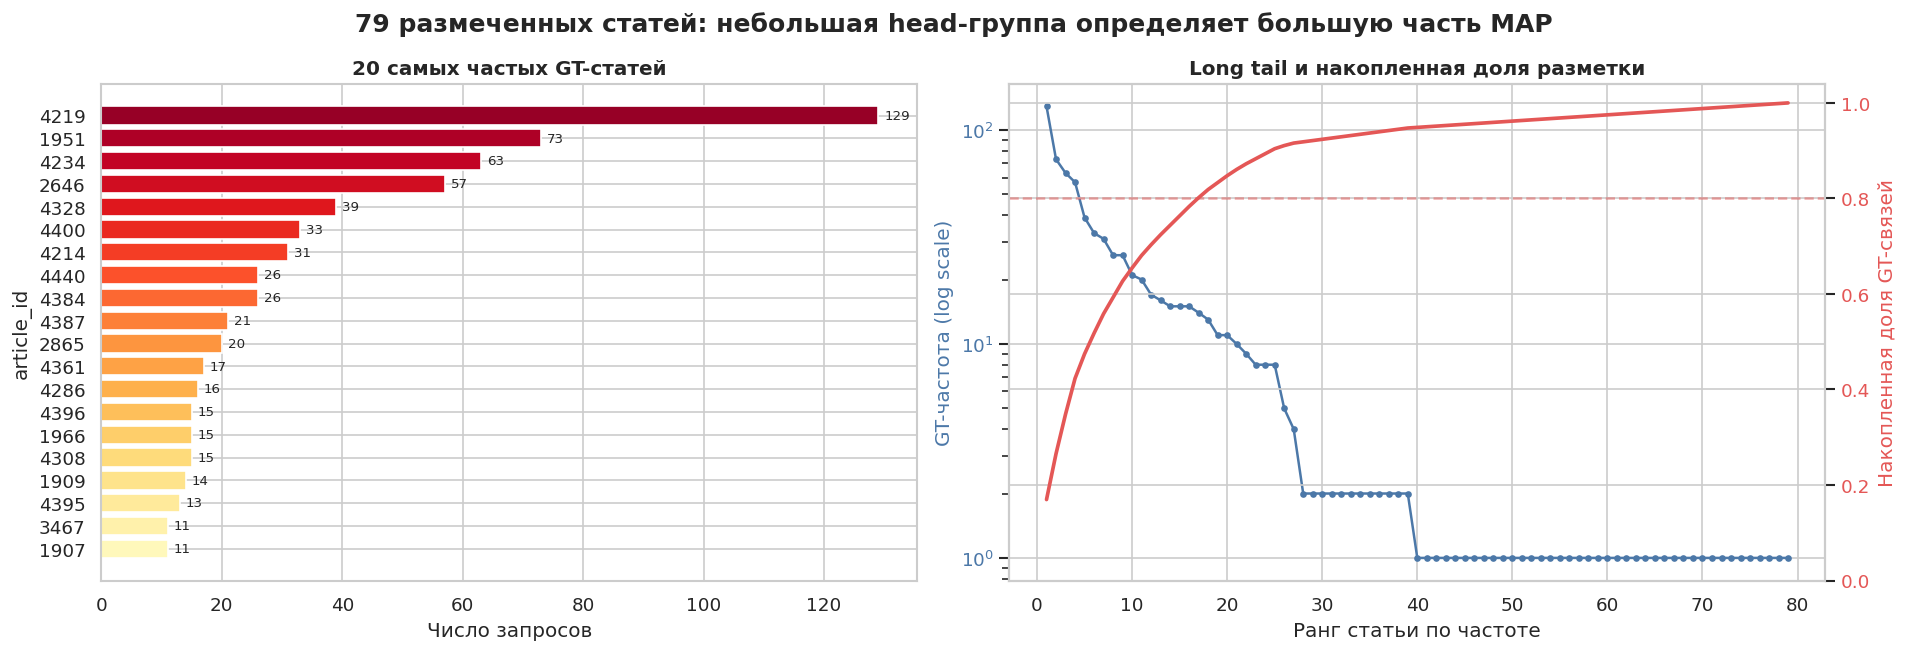

,article_id,title,frequency,cumulative_share
0,4219,Покупателю,129,17.0%
1,1951,Кто оплачивает доставку и сколько она стоит,73,26.5%
2,4234,Как продавать и покупать с доставкой,63,34.8%
3,2646,Оплата заказов с доставкой,57,42.3%
4,4328,Что можно заказать и отправить,39,47.4%
5,4400,Покупателю — отказаться от товара или вернуть его,33,51.8%
6,4214,"Скидки, бонусы и промокоды",31,55.8%
7,4384,Баланс для покупок,26,59.3%
8,4440,"Платёж прошёл, но есть проблема",26,62.7%
9,4387,Всё про отмену заказа,21,65.4%


In [6]:
frequency_df = pd.DataFrame(article_frequency.most_common(), columns=["article_id", "frequency"])
frequency_df["rank"] = np.arange(1, len(frequency_df) + 1)
frequency_df["cumulative_share"] = frequency_df["frequency"].cumsum() / frequency_df["frequency"].sum()
frequency_df["title"] = frequency_df["article_id"].map(article_title)

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

top = frequency_df.head(20).sort_values("frequency")
axes[0].barh(top["article_id"].astype(str), top["frequency"], color=sns.color_palette("YlOrRd", len(top)))
axes[0].set_title("20 самых частых GT-статей")
axes[0].set_xlabel("Число запросов")
axes[0].set_ylabel("article_id")
for index, row in enumerate(top.itertuples()):
    axes[0].text(row.frequency + 1, index, str(row.frequency), va="center", fontsize=8)

axes[1].plot(frequency_df["rank"], frequency_df["frequency"], marker="o", markersize=3, color="#4C78A8", label="GT-частота")
axes[1].set_yscale("log")
axes[1].set_xlabel("Ранг статьи по частоте")
axes[1].set_ylabel("GT-частота (log scale)", color="#4C78A8")
axes[1].tick_params(axis="y", labelcolor="#4C78A8")
axes[1].set_title("Long tail и накопленная доля разметки")

ax_share = axes[1].twinx()
ax_share.plot(frequency_df["rank"], frequency_df["cumulative_share"], color="#E45756", linewidth=2.2, label="Накопленная доля")
ax_share.axhline(0.8, color="#E45756", linestyle="--", alpha=0.5)
ax_share.set_ylabel("Накопленная доля GT-связей", color="#E45756")
ax_share.tick_params(axis="y", labelcolor="#E45756")
ax_share.set_ylim(0, 1.04)

fig.suptitle("79 размеченных статей: небольшая head-группа определяет большую часть MAP", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()
display(frequency_df.head(15)[["article_id", "title", "frequency", "cumulative_share"]].style.format({"cumulative_share": "{:.1%}"}))

## 5. Связь FT-прироста с частотой статьи в train-фолде

Для каждого dev-запроса частота считается только по train-части его фолда. Поэтому нулевая частота действительно означает, что модель фолда не видела ни одной GT-статьи запроса как позитив.

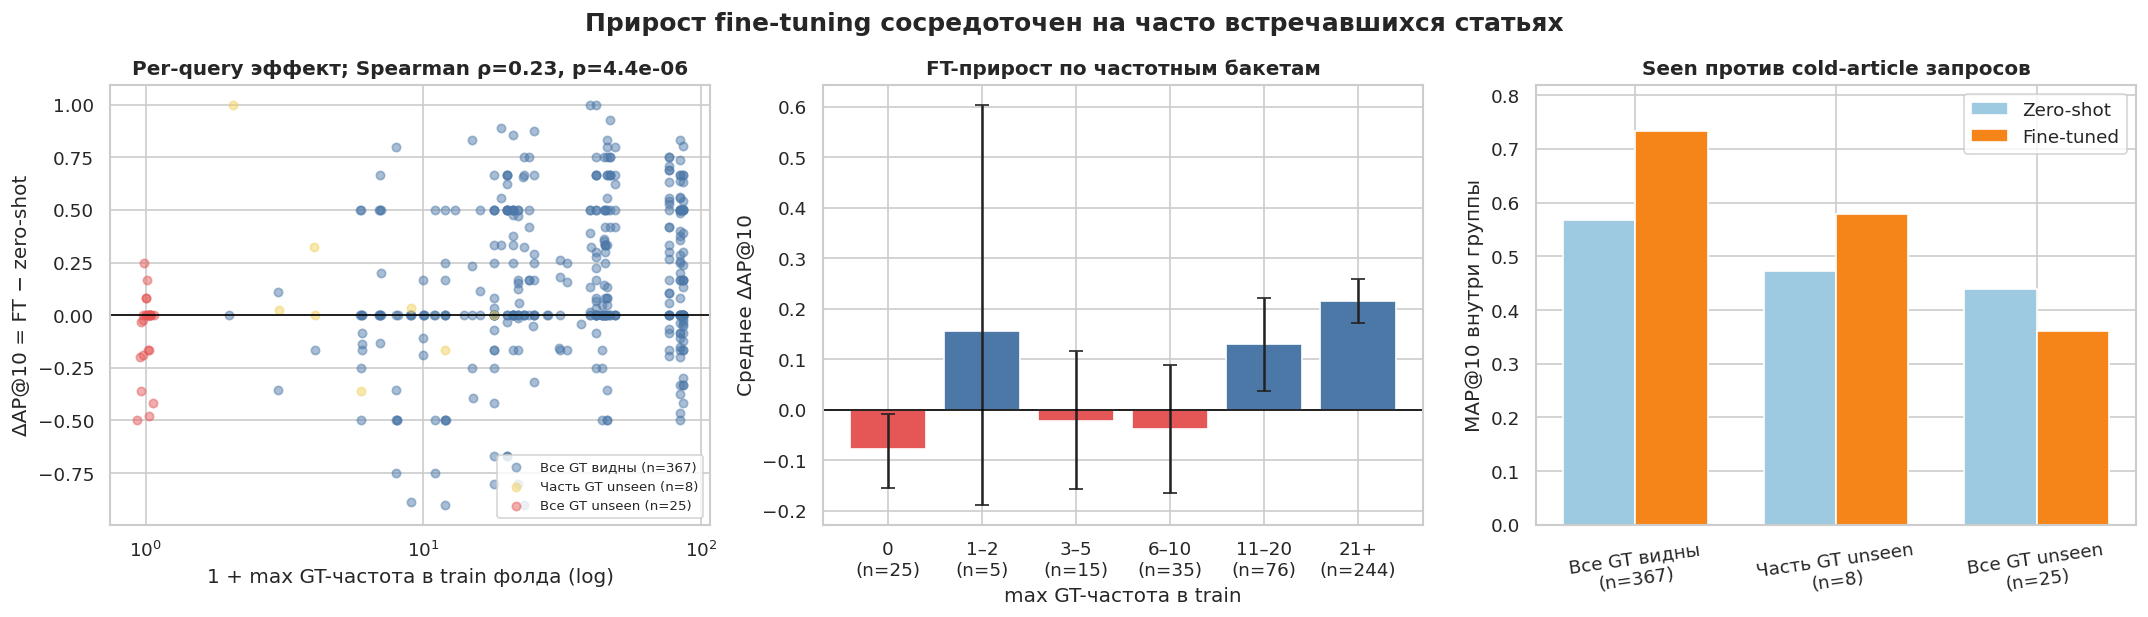

,group,n,zs,ft,delta,low,high
0,Все GT видны,367,0.568,0.733,+0.165,+0.127,+0.203
1,Часть GT unseen,8,0.473,0.580,+0.106,-0.120,+0.390
2,Все GT unseen,25,0.439,0.361,-0.078,-0.155,-0.010


,group,n,zero-shot,fine-tuned,delta
0,Giant component,361,0.568,0.729,+0.161
1,Вне giant component,39,0.468,0.501,+0.033


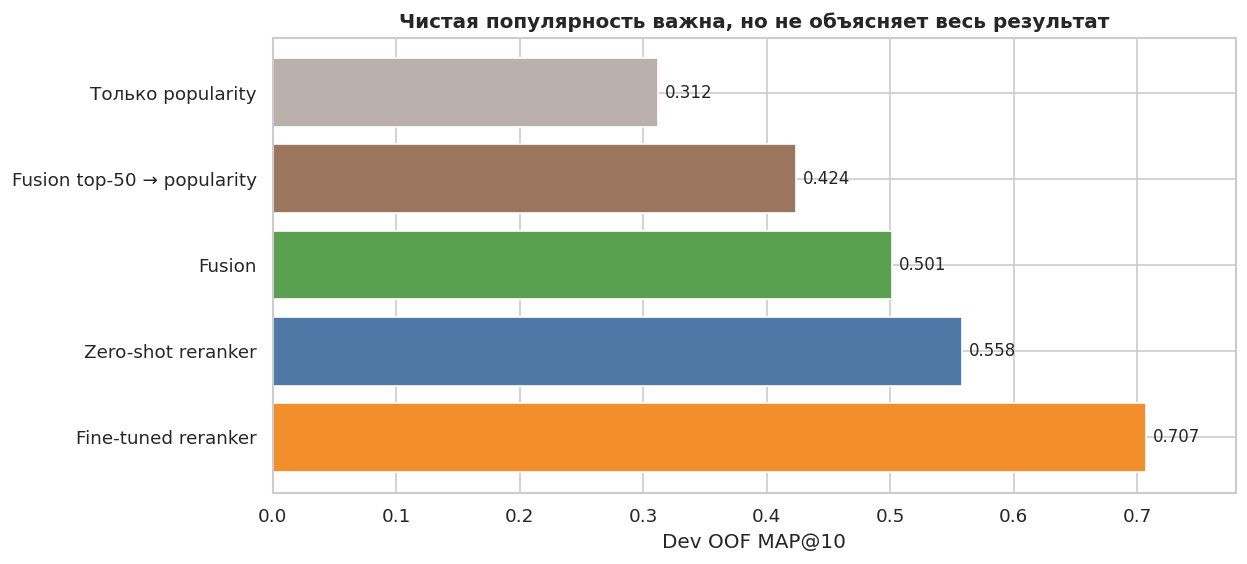

,method,MAP@10
0,Только popularity,0.3117
1,Fusion top-50 → popularity,0.4238
2,Fusion,0.5012
3,Zero-shot reranker,0.5584
4,Fine-tuned reranker,0.7070


In [7]:
dev_frequency = Counter(aid for qid in dev_ids for aid in gt[qid])
fold_frequency = {fold: Counter() for fold in sorted(set(fold_of.values()))}
for qid in dev_ids:
    fold_frequency[fold_of[qid]].update(gt[qid])

diagnostic_rows = []
for qid in sorted(dev_ids):
    fold = fold_of[qid]
    train_freqs = [dev_frequency[aid] - fold_frequency[fold][aid] for aid in gt[qid]]
    zs_ap = ap_at_10(zs_rank[qid], gt[qid])
    ft_ap = ap_at_10(ft_rank[qid], gt[qid])
    unseen = sum(freq == 0 for freq in train_freqs)
    if unseen == 0:
        novelty = "Все GT видны"
    elif unseen == len(train_freqs):
        novelty = "Все GT unseen"
    else:
        novelty = "Часть GT unseen"
    diagnostic_rows.append({
        "query_id": qid, "zs_ap": zs_ap, "ft_ap": ft_ap, "delta": ft_ap - zs_ap,
        "freq_max": max(train_freqs), "freq_min": min(train_freqs), "freq_sum": sum(train_freqs),
        "novelty": novelty, "n_gt": len(train_freqs),
    })
diagnostic_df = pd.DataFrame(diagnostic_rows)
rho, rho_p = spearmanr(diagnostic_df["freq_max"], diagnostic_df["delta"])

bin_edges = [-1, 0, 2, 5, 10, 20, np.inf]
bin_labels = ["0", "1–2", "3–5", "6–10", "11–20", "21+"]
diagnostic_df["freq_bin"] = pd.cut(diagnostic_df["freq_max"], bins=bin_edges, labels=bin_labels)

rng = np.random.default_rng(42)
def bootstrap_mean_ci(values: pd.Series, n_resamples: int = 10_000) -> tuple[float, float, float]:
    array = values.to_numpy(dtype=float)
    sampled = array[rng.integers(0, len(array), size=(n_resamples, len(array)))]
    means = sampled.mean(axis=1)
    return float(array.mean()), *np.quantile(means, [0.025, 0.975]).tolist()

bin_rows = []
for label in bin_labels:
    subset = diagnostic_df.loc[diagnostic_df["freq_bin"] == label, "delta"]
    if len(subset):
        mean, low, high = bootstrap_mean_ci(subset)
        bin_rows.append({"freq_bin": label, "n": len(subset), "mean": mean, "low": low, "high": high})
bin_df = pd.DataFrame(bin_rows)

novelty_order = ["Все GT видны", "Часть GT unseen", "Все GT unseen"]
novelty_rows = []
for label in novelty_order:
    subset = diagnostic_df.loc[diagnostic_df["novelty"] == label]
    mean, low, high = bootstrap_mean_ci(subset["delta"])
    novelty_rows.append({
        "group": label, "n": len(subset), "zs": subset["zs_ap"].mean(), "ft": subset["ft_ap"].mean(),
        "delta": mean, "low": low, "high": high,
    })
novelty_df = pd.DataFrame(novelty_rows)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.2))
palette = {"Все GT видны": "#4C78A8", "Часть GT unseen": "#F2CF5B", "Все GT unseen": "#E45756"}
for label in novelty_order:
    subset = diagnostic_df[diagnostic_df["novelty"] == label]
    jitter = rng.normal(0, 0.035, len(subset))
    axes[0].scatter(subset["freq_max"] + 1 + jitter, subset["delta"], s=25, alpha=0.48, label=f"{label} (n={len(subset)})", color=palette[label])
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_xscale("log")
axes[0].set_xlabel("1 + max GT-частота в train фолда (log)")
axes[0].set_ylabel("ΔAP@10 = FT − zero-shot")
axes[0].set_title(f"Per-query эффект; Spearman ρ={rho:.2f}, p={rho_p:.1e}")
axes[0].legend(fontsize=8, loc="lower right")

x = np.arange(len(bin_df))
axes[1].bar(x, bin_df["mean"], color=["#E45756" if value < 0 else "#4C78A8" for value in bin_df["mean"]])
axes[1].errorbar(x, bin_df["mean"], yerr=[bin_df["mean"] - bin_df["low"], bin_df["high"] - bin_df["mean"]], fmt="none", ecolor="#222222", capsize=4)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_xticks(x, [f"{row.freq_bin}\n(n={row.n})" for row in bin_df.itertuples()])
axes[1].set_xlabel("max GT-частота в train")
axes[1].set_ylabel("Среднее ΔAP@10")
axes[1].set_title("FT-прирост по частотным бакетам")

x = np.arange(len(novelty_df))
width = 0.36
axes[2].bar(x - width / 2, novelty_df["zs"], width, label="Zero-shot", color="#9ECAE1")
axes[2].bar(x + width / 2, novelty_df["ft"], width, label="Fine-tuned", color="#F58518")
axes[2].set_xticks(x, [f"{row.group}\n(n={row.n})" for row in novelty_df.itertuples()], rotation=8)
axes[2].set_ylabel("MAP@10 внутри группы")
axes[2].set_title("Seen против cold-article запросов")
axes[2].legend()
axes[2].set_ylim(0, 0.82)

fig.suptitle("Прирост fine-tuning сосредоточен на часто встречавшихся статьях", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

display(novelty_df[["group", "n", "zs", "ft", "delta", "low", "high"]].style.format({
    "zs": "{:.3f}", "ft": "{:.3f}", "delta": "{:+.3f}", "low": "{:+.3f}", "high": "{:+.3f}",
}))

# Stress-test по компонентам: giant component против всего tail.
giant_query_ids = {node[1] for node in components[0] if node[0] == "q"}
component_rows = []
for group_name, query_ids in [
    ("Giant component", dev_ids & giant_query_ids),
    ("Вне giant component", dev_ids - giant_query_ids),
]:
    zs_values = [ap_at_10(zs_rank[qid], gt[qid]) for qid in query_ids]
    ft_values = [ap_at_10(ft_rank[qid], gt[qid]) for qid in query_ids]
    component_rows.append({
        "group": group_name, "n": len(query_ids),
        "zero-shot": np.mean(zs_values), "fine-tuned": np.mean(ft_values),
        "delta": np.mean(np.asarray(ft_values) - np.asarray(zs_values)),
    })
component_effect_df = pd.DataFrame(component_rows)
display(component_effect_df.style.format({
    "zero-shot": "{:.3f}", "fine-tuned": "{:.3f}", "delta": "{:+.3f}",
}))

# Popularity baselines: отделяем чистую частоту от семантического matching.
fusion_cal = load_score_matrix(SOLUTION / "artifacts_rr_bge_ft_labeled/scores/fusion/calibration.npz")
fusion_rank = rankings(fusion_cal, 50)
all_article_ids = articles["article_id"].astype(int).tolist()
popularity_all = {}
popularity_in_candidates = {}
for qid in sorted(dev_ids):
    fold = fold_of[qid]
    train_frequency = Counter({
        aid: dev_frequency[aid] - fold_frequency[fold][aid]
        for aid in dev_frequency
    })
    popularity_all[qid] = sorted(all_article_ids, key=lambda aid: (-train_frequency[aid], aid))[:50]
    candidates = fusion_rank[qid]
    candidate_position = {aid: position for position, aid in enumerate(candidates)}
    popularity_in_candidates[qid] = sorted(
        candidates, key=lambda aid: (-train_frequency[aid], candidate_position[aid])
    )

def map_for(rank: dict[int, list[int]]) -> float:
    return float(np.mean([ap_at_10(rank[qid], gt[qid]) for qid in dev_ids]))

baseline_df = pd.DataFrame({
    "method": [
        "Только popularity", "Fusion top-50 → popularity", "Fusion",
        "Zero-shot reranker", "Fine-tuned reranker",
    ],
    "MAP@10": [
        map_for(popularity_all), map_for(popularity_in_candidates), map_for(fusion_rank),
        map_for(zs_rank), map_for(ft_rank),
    ],
})
fig, ax = plt.subplots(figsize=(10.5, 4.8))
colors = ["#BAB0AC", "#9C755F", "#59A14F", "#4E79A7", "#F28E2B"]
bars = ax.barh(baseline_df["method"], baseline_df["MAP@10"], color=colors)
ax.bar_label(bars, labels=[f"{value:.3f}" for value in baseline_df["MAP@10"]], padding=4)
ax.set_xlim(0, 0.78)
ax.set_xlabel("Dev OOF MAP@10")
ax.set_title("Чистая популярность важна, но не объясняет весь результат")
ax.invert_yaxis()
plt.tight_layout()
plt.show()
display(baseline_df.style.format({"MAP@10": "{:.4f}"}))

## 6. Как FT меняет распределение предсказаний на test

Для test нет ground truth, поэтому здесь нельзя измерить качество по head/tail. Можно измерить только **поведение выдачи**: сколько разных статей модель использует и какая доля top-1 концентрируется на популярных статьях calibration.

Вместо графа с чёрными вершинами используются три прямых представления:

1. состав top-1: десять самых частых статей / остальные известные / статьи вне 79;
2. cumulative concentration curve — сколько top-1 покрывают первые N статей;
3. dumbbell — какие конкретно статьи получили или потеряли top-1 после FT.

Это по-прежнему не доказывает релевантность test-предсказаний, но честно показывает усиление article-popularity prior.

,model,unique top-1,unique top-10,top-1 из 79 GT-статей,top-1 из top-10 частых,доля самой частой top-1,HHI top-1
0,Zero-shot blend,103,385,76.4%,31.4%,11.4%,0.0355
1,FT blend,71,353,88.2%,68.8%,25.8%,0.0997


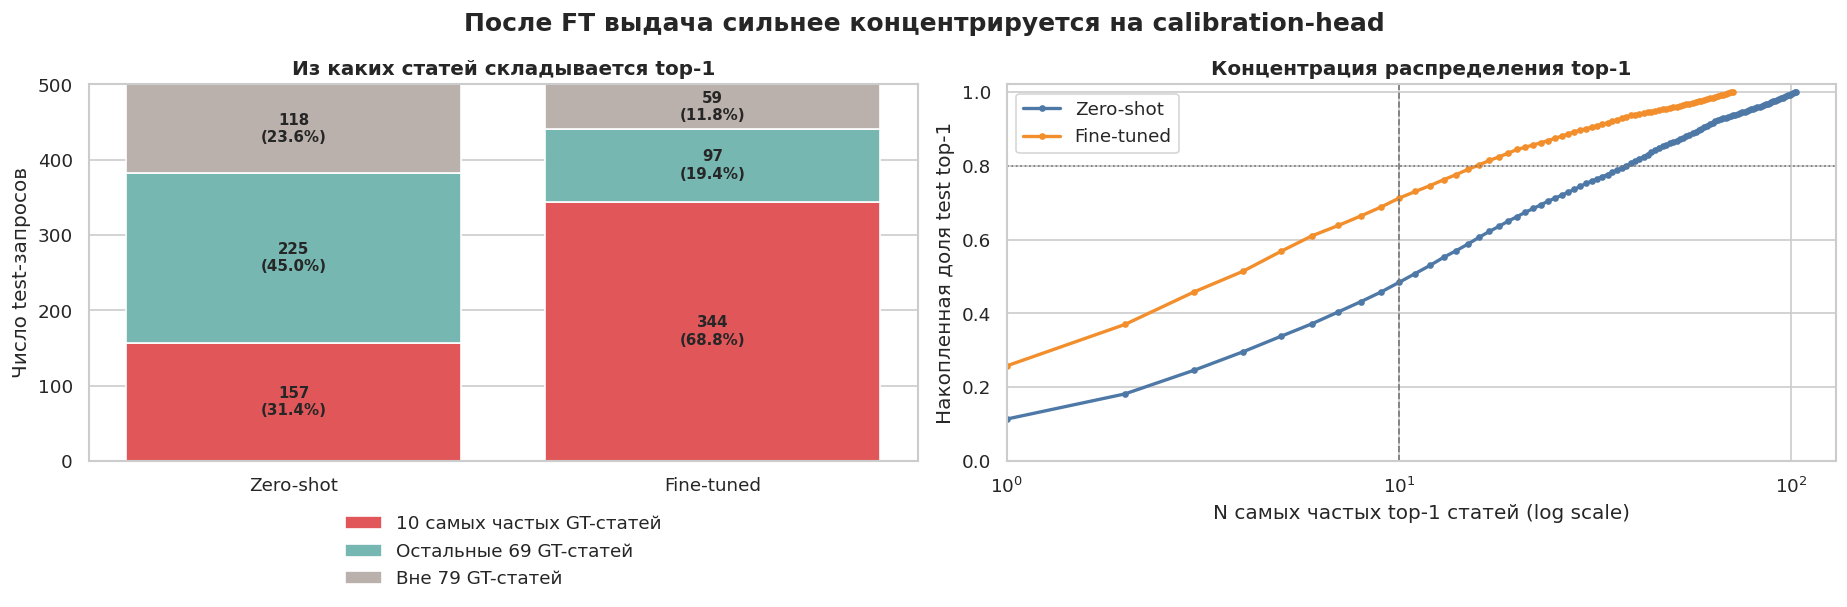

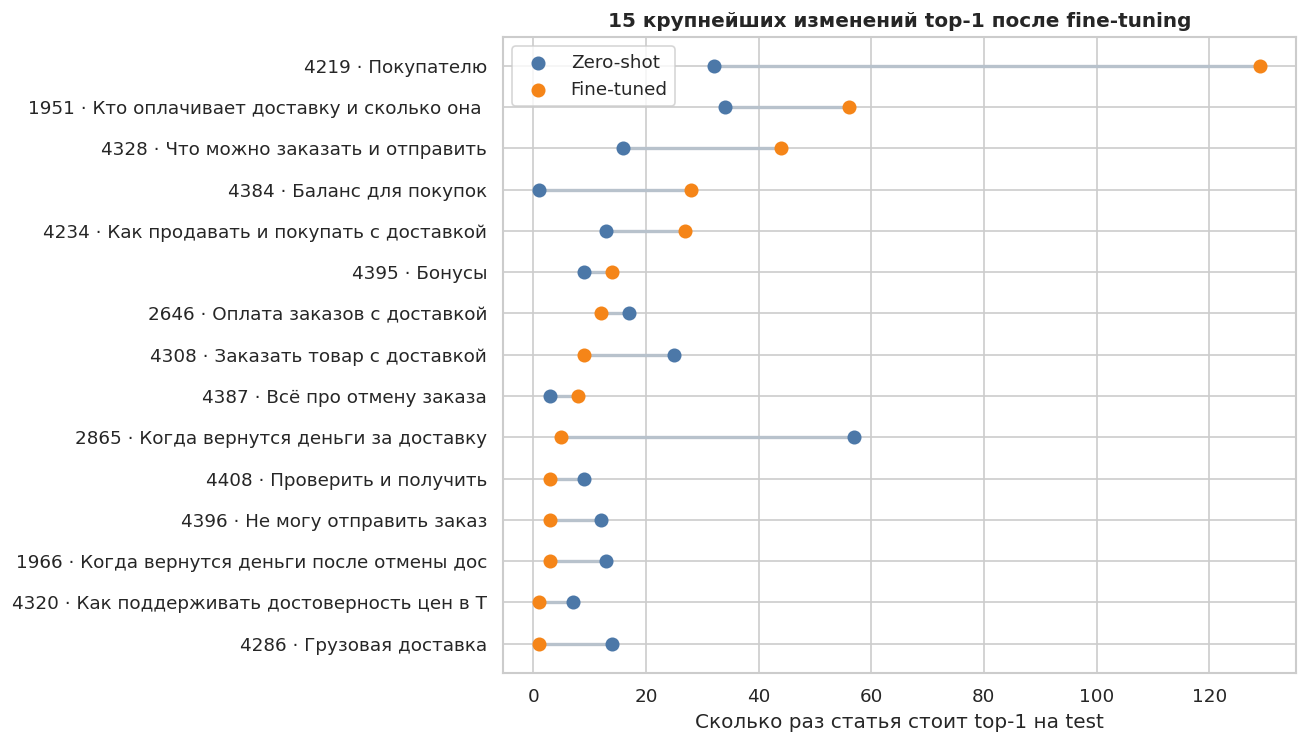

In [8]:
zs_test = load_score_matrix(SOLUTION / "artifacts_rr_bge_zs_c40/scores/blend/test.npz")
ft_test = load_score_matrix(SOLUTION / "artifacts_rr_bge_ft_labeled/scores/blend/test.npz")
zs_test_rank = rankings(zs_test, 10)
ft_test_rank = rankings(ft_test, 10)
zs_top1 = Counter(result[0] for result in zs_test_rank.values())
ft_top1 = Counter(result[0] for result in ft_test_rank.values())
known = set(labeled_articles)
top10_frequent = {aid for aid, _ in article_frequency.most_common(10)}

def prediction_stats(name: str, rank: dict[int, list[int]]) -> dict[str, object]:
    top1 = [result[0] for result in rank.values()]
    top10 = [aid for result in rank.values() for aid in result]
    counts = Counter(top1)
    probabilities = np.array(list(counts.values()), dtype=float) / len(top1)
    return {
        "model": name,
        "unique top-1": len(set(top1)),
        "unique top-10": len(set(top10)),
        "top-1 из 79 GT-статей": np.mean([aid in known for aid in top1]),
        "top-1 из top-10 частых": np.mean([aid in top10_frequent for aid in top1]),
        "доля самой частой top-1": max(counts.values()) / len(top1),
        "HHI top-1": np.sum(probabilities ** 2),
    }

prediction_summary = pd.DataFrame([
    prediction_stats("Zero-shot blend", zs_test_rank),
    prediction_stats("FT blend", ft_test_rank),
])
display(prediction_summary.style.format({
    "top-1 из 79 GT-статей": "{:.1%}", "top-1 из top-10 частых": "{:.1%}",
    "доля самой частой top-1": "{:.1%}", "HHI top-1": "{:.4f}",
}))

def top1_composition(counts: Counter) -> list[int]:
    return [
        sum(count for aid, count in counts.items() if aid in top10_frequent),
        sum(count for aid, count in counts.items() if aid in known - top10_frequent),
        sum(count for aid, count in counts.items() if aid not in known),
    ]

fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.2))
model_names = ["Zero-shot", "Fine-tuned"]
composition = np.array([top1_composition(zs_top1), top1_composition(ft_top1)])
category_names = ["10 самых частых GT-статей", "Остальные 69 GT-статей", "Вне 79 GT-статей"]
category_colors = ["#E15759", "#76B7B2", "#BAB0AC"]
bottom = np.zeros(2)
for category_index, category_name in enumerate(category_names):
    values = composition[:, category_index]
    bars = axes[0].bar(model_names, values, bottom=bottom, color=category_colors[category_index], label=category_name)
    for model_index, value in enumerate(values):
        if value >= 25:
            axes[0].text(model_index, bottom[model_index] + value / 2, f"{value}\n({value / len(test):.1%})",
                         ha="center", va="center", fontsize=9, fontweight="bold")
    bottom += values
axes[0].set_ylim(0, len(test))
axes[0].set_ylabel("Число test-запросов")
axes[0].set_title("Из каких статей складывается top-1")
axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), frameon=False)

for name, counts, color in [("Zero-shot", zs_top1, "#4E79A7"), ("Fine-tuned", ft_top1, "#F28E2B")]:
    sorted_counts = np.array(sorted(counts.values(), reverse=True), dtype=float)
    cumulative = np.cumsum(sorted_counts) / sorted_counts.sum()
    axes[1].plot(np.arange(1, len(cumulative) + 1), cumulative, marker="o", markersize=3, linewidth=2, label=name, color=color)
axes[1].axvline(10, color="#777777", linestyle="--", linewidth=1)
axes[1].axhline(0.8, color="#777777", linestyle=":", linewidth=1)
axes[1].set_xscale("log")
axes[1].set_xlim(1, 130)
axes[1].set_ylim(0, 1.02)
axes[1].set_xlabel("N самых частых top-1 статей (log scale)")
axes[1].set_ylabel("Накопленная доля test top-1")
axes[1].set_title("Концентрация распределения top-1")
axes[1].legend()
fig.suptitle("После FT выдача сильнее концентрируется на calibration-head", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

candidate_ids = {aid for aid, _ in zs_top1.most_common(20)} | {aid for aid, _ in ft_top1.most_common(20)}
comparison_ids = sorted(candidate_ids, key=lambda aid: abs(ft_top1[aid] - zs_top1[aid]), reverse=True)[:15]
top1_comparison = pd.DataFrame({
    "article_id": comparison_ids,
    "title": [article_title.get(aid, "") for aid in comparison_ids],
    "zero_shot": [zs_top1[aid] for aid in comparison_ids],
    "fine_tuned": [ft_top1[aid] for aid in comparison_ids],
}).sort_values("fine_tuned")

fig, ax = plt.subplots(figsize=(11, 6.3))
y = np.arange(len(top1_comparison))
ax.hlines(y, top1_comparison["zero_shot"], top1_comparison["fine_tuned"], color="#B8C2CC", linewidth=2)
ax.scatter(top1_comparison["zero_shot"], y, color="#4C78A8", s=55, label="Zero-shot", zorder=3)
ax.scatter(top1_comparison["fine_tuned"], y, color="#F58518", s=55, label="Fine-tuned", zorder=3)
ax.set_yticks(y, [f"{row.article_id} · {row.title[:38]}" for row in top1_comparison.itertuples()])
ax.set_xlabel("Сколько раз статья стоит top-1 на test")
ax.set_title("15 крупнейших изменений top-1 после fine-tuning")
ax.legend()
plt.tight_layout()
plt.show()

## Выводы и границы интерпретации

1. **Связность:** giant component объединяет 453 запроса, но только 32 статьи. Её центр — доставка, оплата, отмена и возврат денег; хаб `4219` связан с `2646` в 45 запросах.
2. **Head–tail:** top-10 статей дают около 65% всех положительных связей, а 40 из 79 размеченных статей встречаются ровно один раз. Query-level OOF поэтому в основном проверяет новые формулировки для знакомых статей.
3. **Эффект FT:** на 367 запросах, где все GT видны в train-фолде, FT даёт сильный прирост. На 25 полностью cold-article запросах средний эффект отрицательный. В giant component прирост намного выше, чем вне неё.
4. **Не только popularity:** чистый частотный baseline существенно слабее fusion, zero-shot и FT. Следовательно, семантический matching остаётся необходимым.
5. **Test без GT:** после FT распределение top-1 становится менее разнообразным и сильнее концентрируется на десяти самых частых calibration-статьях. Это наблюдение о поведении, а не доказательство test-релевантности.

Корректная итоговая формулировка: **fine-tuned система сочетает более сильный семантический matching на знакомых темах с выраженным article-popularity prior; этот prior полезен при стационарном распределении, но ухудшает cold-article generalization.**

___

## 7. Граф внутренних HTML-ссылок между статьями

Это **другой тип ребра**. Направленное ребро `A → B` существует, если HTML статьи A содержит ссылку вида `/articles/B`. В отличие от co-label-графа, оно строится без разметки запросов и доступно для всех 793 статей.

Два графа отвечают на разные вопросы:

- co-label: «какие статьи разметчики считают совместно релевантными одному запросу?»;
- HTML-link: «на какие дополнительные материалы отправляет сама статья?».

Сначала — масштаб ссылочного графа всего корпуса, затем наложение ссылок на уже знакомую радиальную карту 32 статей. Полный граф из 793 вершин намеренно не рисуется force-directed раскладкой: он содержит сотни вершин и более тысячи рёбер и превращается в нечитаемый клубок.

,metric,value
0,Статей,793
1,Направленных HTML-ссылок,1174
2,Статей с исходящими ссылками,458
3,Статей с входящими ссылками,348
4,Слабых компонент,240
5,Изолированных статей,234
6,HTML-ссылок внутри 79 GT-статей,52
7,"GT-статей, участвующих во внутренних ссылках",35
8,"Co-label рёбер, подтверждённых HTML-ссылкой",19/99 (19.2%)
9,"Доля веса co-label, подтверждённая ссылкой",73/302 (24.2%)


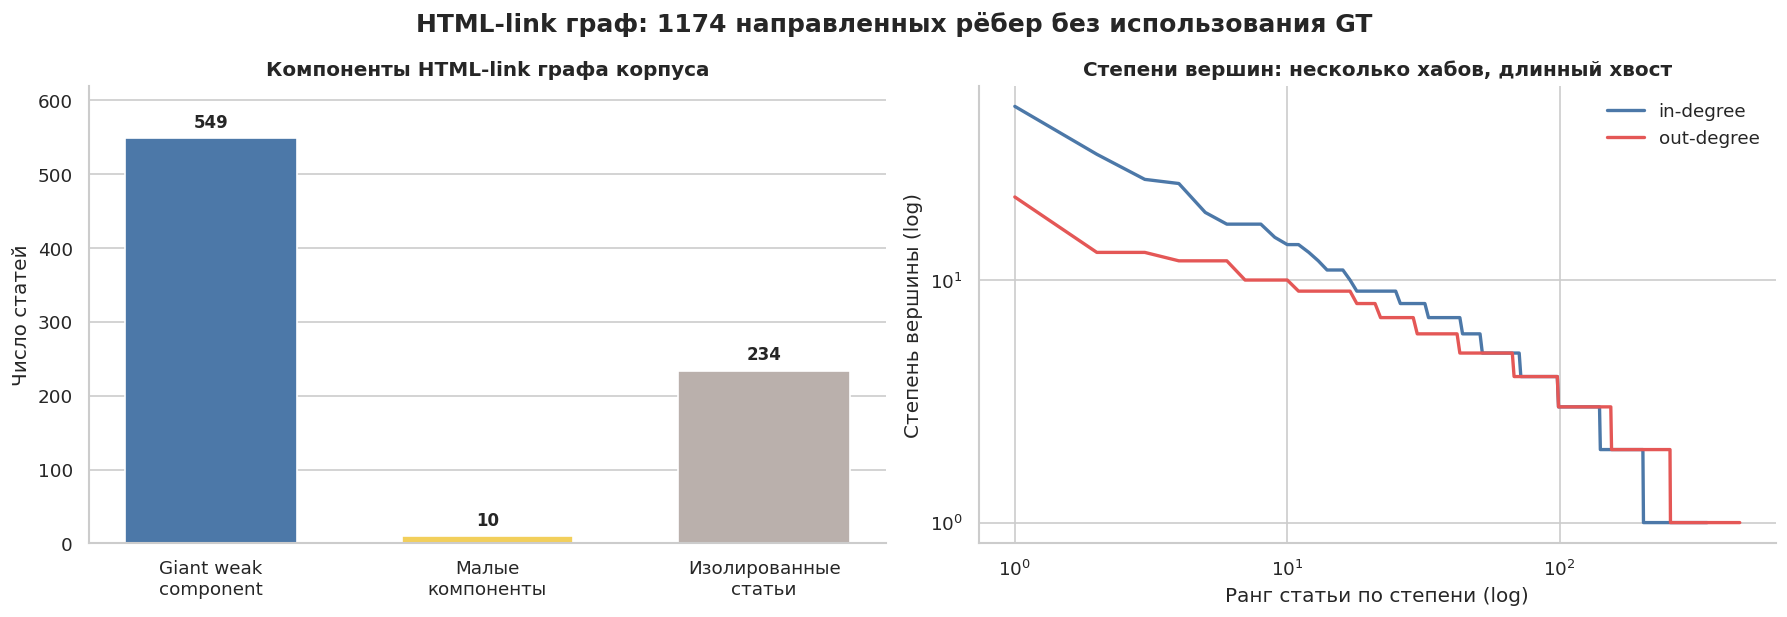

In [9]:
article_ids_set = set(articles["article_id"].astype(int))
article_link_pattern = re.compile(r"/articles/(\d+)")
link_graph = nx.DiGraph()
link_graph.add_nodes_from(article_ids_set)
for row in articles.itertuples():
    source = int(row.article_id)
    targets = dict.fromkeys(int(value) for value in article_link_pattern.findall(str(row.body)))
    for target in targets:
        if target in article_ids_set and target != source:
            link_graph.add_edge(source, target)

weak_components = sorted(nx.weakly_connected_components(link_graph), key=len, reverse=True)
isolated_articles = list(nx.isolates(link_graph))
nontrivial_tail_nodes = sum(len(component) for component in weak_components[1:] if len(component) > 1)
labeled_link_graph = link_graph.subgraph(labeled_articles)

co_label_edges = {tuple(sorted(edge)) for edge in P.edges()}
link_edges_undirected = {tuple(sorted(edge)) for edge in link_graph.edges()}
labeled_link_edges = {edge for edge in link_edges_undirected if edge[0] in set(labeled_articles) and edge[1] in set(labeled_articles)}
overlap_edges = co_label_edges & link_edges_undirected
co_label_weight_total = sum(P[left][right]["weight"] for left, right in P.edges())
overlap_weight = sum(P[left][right]["weight"] for left, right in overlap_edges)

link_summary = pd.DataFrame({
    "metric": [
        "Статей", "Направленных HTML-ссылок", "Статей с исходящими ссылками",
        "Статей с входящими ссылками", "Слабых компонент", "Изолированных статей",
        "HTML-ссылок внутри 79 GT-статей", "GT-статей, участвующих во внутренних ссылках",
        "Co-label рёбер, подтверждённых HTML-ссылкой", "Доля веса co-label, подтверждённая ссылкой",
    ],
    "value": [
        link_graph.number_of_nodes(), link_graph.number_of_edges(),
        sum(link_graph.out_degree(node) > 0 for node in link_graph),
        sum(link_graph.in_degree(node) > 0 for node in link_graph),
        len(weak_components), len(isolated_articles), labeled_link_graph.number_of_edges(),
        sum(labeled_link_graph.degree(node) > 0 for node in labeled_link_graph),
        f"{len(overlap_edges)}/{len(co_label_edges)} ({len(overlap_edges) / len(co_label_edges):.1%})",
        f"{overlap_weight}/{co_label_weight_total} ({overlap_weight / co_label_weight_total:.1%})",
    ],
})
display(link_summary)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
component_counts = [len(weak_components[0]), nontrivial_tail_nodes, len(isolated_articles)]
component_labels = ["Giant weak\ncomponent", "Малые\nкомпоненты", "Изолированные\nстатьи"]
bars = axes[0].bar(component_labels, component_counts, color=["#4C78A8", "#F2CF5B", "#BAB0AC"], width=0.62)
axes[0].bar_label(bars, padding=4, fontweight="bold")
axes[0].set_ylim(0, 620)
axes[0].set_ylabel("Число статей")
axes[0].set_title("Компоненты HTML-link графа корпуса")
axes[0].grid(axis="x", visible=False)

out_degrees = np.array(sorted((degree for _, degree in link_graph.out_degree() if degree > 0), reverse=True))
in_degrees = np.array(sorted((degree for _, degree in link_graph.in_degree() if degree > 0), reverse=True))
axes[1].plot(np.arange(1, len(in_degrees) + 1), in_degrees, color="#4C78A8", linewidth=2, label="in-degree")
axes[1].plot(np.arange(1, len(out_degrees) + 1), out_degrees, color="#E45756", linewidth=2, label="out-degree")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("Ранг статьи по степени (log)")
axes[1].set_ylabel("Степень вершины (log)")
axes[1].set_title("Степени вершин: несколько хабов, длинный хвост")
axes[1].legend(frameon=False)
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
fig.suptitle(
    f"HTML-link граф: {link_graph.number_of_edges()} направленных рёбер без использования GT",
    fontsize=15, fontweight="bold",
)
plt.tight_layout()
plt.show()

### Наложение HTML-ссылок на giant co-label component

Положение и цвет статей полностью сохранены с радиальной карты выше. Серое ребро — сильная co-label связь, бирюзовая стрелка — HTML-ссылка без совместной разметки, фиолетовая стрелка — HTML-ссылка и co-label связь одновременно. Поэтому геометрию двух графов можно сравнивать напрямую.

Форма вершины показывает исходящие ссылки за границу показанной компоненты: **квадрат** — статья содержит хотя бы одну HTML-ссылку на статью вне giant component; **круг** — таких исходящих ссылок нет. Входящая ссылка снаружи сама по себе форму не меняет.

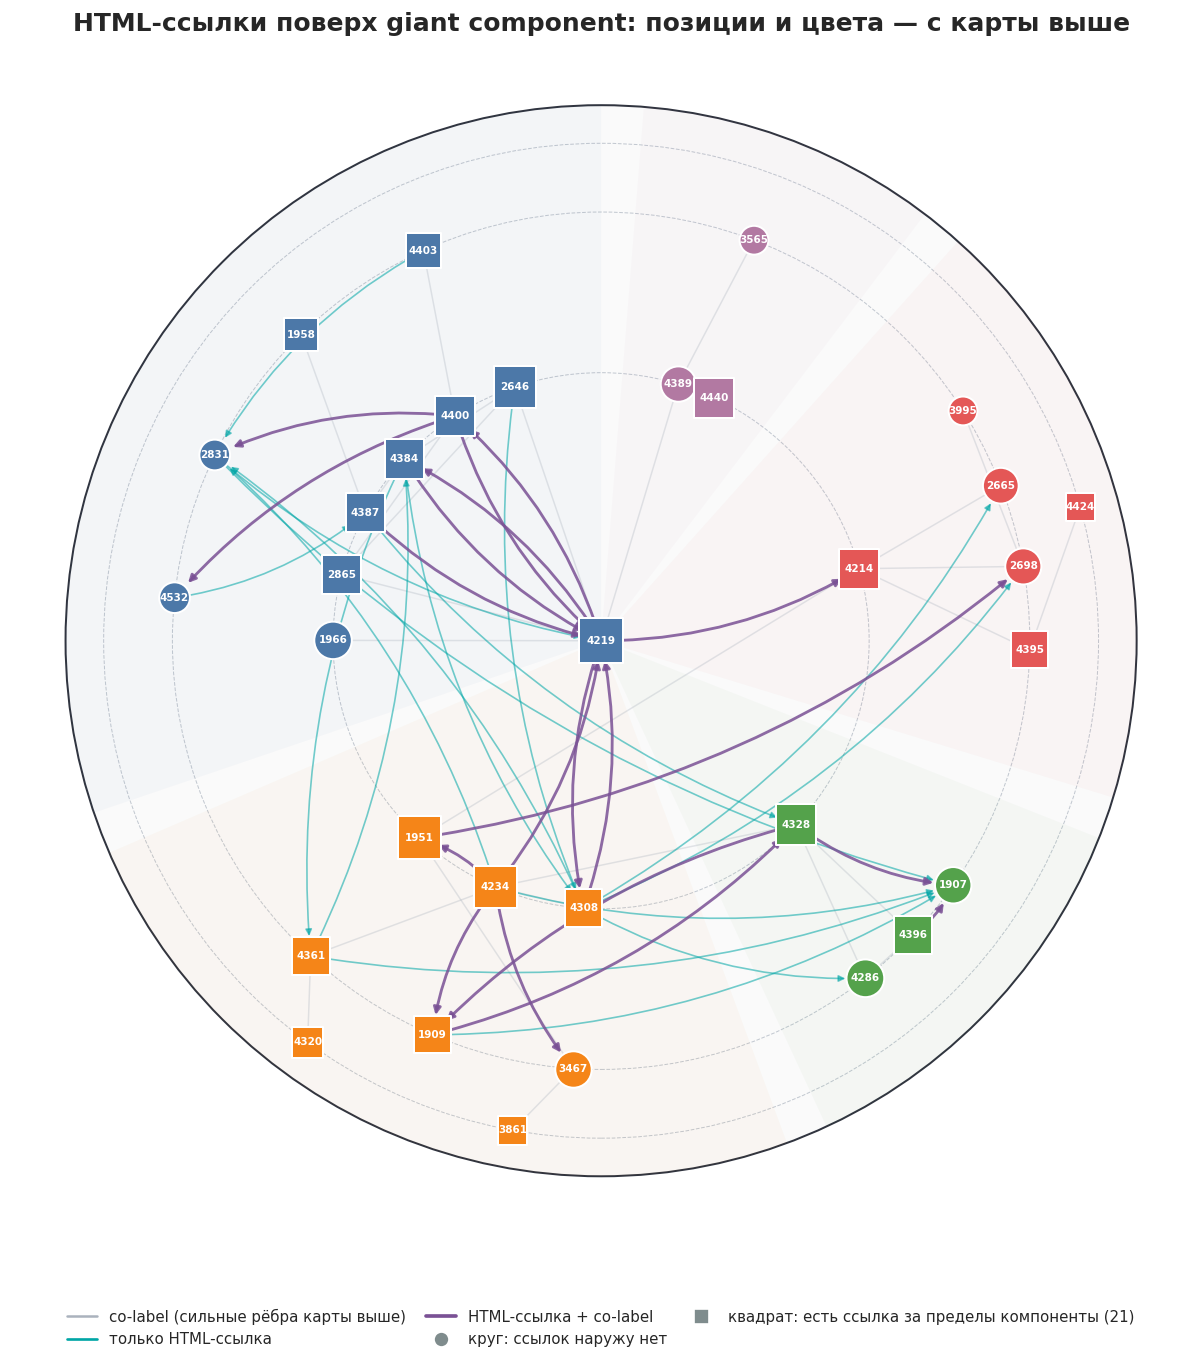

,articles,HTML direction,co-label weight,left title,right title
0,4219 — 4384,"4219 → 4384, 4384 → 4219",15,Покупателю,Баланс для покупок
1,1951 — 4234,4234 → 1951,13,Кто оплачивает доставку и сколько она стоит,Как продавать и покупать с доставкой
2,4219 — 4400,"4219 → 4400, 4400 → 4219",9,Покупателю,Покупателю — отказаться от товара или вернуть его
3,4219 — 4387,4387 → 4219,6,Покупателю,Всё про отмену заказа
4,1909 — 4234,4234 → 1909,5,Отправить заказ,Как продавать и покупать с доставкой
5,4219 — 4234,4234 → 4219,4,Покупателю,Как продавать и покупать с доставкой
6,4214 — 4219,4219 → 4214,3,"Скидки, бонусы и промокоды",Покупателю
7,1907 — 4396,4396 → 1907,3,Упаковать товар,Не могу отправить заказ
8,4219 — 4308,"4219 → 4308, 4308 → 4219",3,Покупателю,Заказать товар с доставкой
9,2831 — 4400,4400 → 2831,2,Приехал повреждённый товар,Покупателю — отказаться от товара или вернуть его


In [10]:
giant_link_edges = [
    (left, right) for left, right in link_graph.edges()
    if left in giant_article_nodes and right in giant_article_nodes
]
giant_overlap_directed = [edge for edge in giant_link_edges if tuple(sorted(edge)) in co_label_edges]
giant_link_only_directed = [edge for edge in giant_link_edges if tuple(sorted(edge)) not in co_label_edges]
co_label_only_display = [edge for edge in display_edges if tuple(sorted(edge)) not in link_edges_undirected]
giant_external_link_sources = {
    source for source, target in link_graph.edges()
    if source in giant_article_nodes and target not in giant_article_nodes
}

fig, ax = plt.subplots(figsize=(12, 12))
ax.add_patch(Circle((0, 0), 1, facecolor="#FAFAFA", edgecolor="#30343F", linewidth=1.2))
for distance in [1, 2, 3]:
    radius = np.tanh(0.55 * distance)
    ax.add_patch(Circle((0, 0), radius, fill=False, edgecolor="#C2C8D0", linestyle="--", linewidth=0.6))
for community_index, (start, end) in enumerate(sector_bounds):
    ax.add_patch(Wedge(
        (0, 0), 1, np.degrees(start), np.degrees(end),
        facecolor=community_colors[community_index], alpha=0.035, edgecolor="none",
    ))
# Порядок отрисовки = порядок чтения: фон co-label, поверх — редкие ссылки,
# сверху — узлы. Кривизна arc3 разводит встречные стрелки и центр-хаб.
nx.draw_networkx_edges(
    G, position, edgelist=co_label_only_display, ax=ax, edge_color="#AAB2BD",
    width=0.9, alpha=0.32, arrows=False,
)
nx.draw_networkx_edges(
    link_graph, position, edgelist=giant_link_only_directed, ax=ax, edge_color="#00A6A6",
    width=1.0, alpha=0.55, arrows=True, arrowstyle="-|>", arrowsize=8,
    connectionstyle="arc3,rad=0.14", min_source_margin=10, min_target_margin=12,
)
nx.draw_networkx_edges(
    link_graph, position, edgelist=giant_overlap_directed, ax=ax, edge_color="#7A5195",
    width=1.7, alpha=0.85, arrows=True, arrowstyle="-|>", arrowsize=9,
    connectionstyle="arc3,rad=0.14", min_source_margin=10, min_target_margin=12,
)
for community_index, community in enumerate(communities):
    circle_nodes = [aid for aid in community if aid not in giant_external_link_sources]
    square_nodes = [aid for aid in community if aid in giant_external_link_sources]
    for nodes, node_shape in ((circle_nodes, "o"), (square_nodes, "s")):
        if not nodes:
            continue
        nx.draw_networkx_nodes(
            G, position, nodelist=nodes, ax=ax, node_shape=node_shape,
            node_size=[230 + 100 * np.log1p(article_frequency[aid]) for aid in nodes],
            node_color=community_colors[community_index], edgecolors="white", linewidths=1.2,
        )
nx.draw_networkx_labels(
    G, position, labels={aid: str(aid) for aid in G.nodes()},
    font_size=6.2, font_color="white", font_weight="bold", ax=ax,
)
edge_legend = [
    Line2D([0], [0], color="#AAB2BD", lw=1.5, label="co-label (сильные рёбра карты выше)"),
    Line2D([0], [0], color="#00A6A6", lw=1.6, label="только HTML-ссылка"),
    Line2D([0], [0], color="#7A5195", lw=2.2, label="HTML-ссылка + co-label"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor="#7F8C8D",
           markeredgecolor="white", markersize=9, label="круг: ссылок наружу нет"),
    Line2D([0], [0], marker="s", color="none", markerfacecolor="#7F8C8D",
           markeredgecolor="white", markersize=9,
           label=f"квадрат: есть ссылка за пределы компоненты ({len(giant_external_link_sources)})"),
]
ax.legend(handles=edge_legend, loc="lower center", bbox_to_anchor=(0.5, -0.1),
          ncol=3, frameon=False, fontsize=9, columnspacing=1.3)
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.12, 1.12)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title("HTML-ссылки поверх giant component: позиции и цвета — с карты выше", fontsize=15)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

overlap_rows = []
for left, right in sorted(overlap_edges, key=lambda edge: P[edge[0]][edge[1]]["weight"], reverse=True):
    directions = []
    if link_graph.has_edge(left, right):
        directions.append(f"{left} → {right}")
    if link_graph.has_edge(right, left):
        directions.append(f"{right} → {left}")
    overlap_rows.append({
        "articles": f"{left} — {right}",
        "HTML direction": ", ".join(directions),
        "co-label weight": P[left][right]["weight"],
        "left title": article_title[left],
        "right title": article_title[right],
    })
display(pd.DataFrame(overlap_rows).head(20))

### Как это читать

- Прямой HTML-ссылкой подтверждены **19 из 99** co-label рёбер (по суммарному весу — около 24%). Ссылки воспроизводят часть структуры разметки, но большую её часть — нет: это два пересекающихся источника сигнала, а не дубли.
- Обратное тоже верно: бирюзовая стрелка без co-label — не «пропущенная разметчиками» пара. Статья может вести на справочный материал, который не обязан быть ответом на тот же запрос, поэтому трактовать ссылку как псевдо-GT нельзя.
- Надёжная роль ссылок — **защитная**: статью, связанную ссылкой с позитивом, опасно брать в hard negatives без проверки.
- Как ранжирующий признак ссылку нужно проверять OOF отдельно от co-label. Это сделано в §10: в mini-LTR фича `link_top` получила вес ≈ 0 при живом `co_top_w` — на размеченной зоне co-label уже покрывает её сигнал.

___

## 8. FT-выдача: есть ли у кандидата co-label-пара среди top-3

Здесь один квадрат — одно предсказание `(test-запрос, rank)` fine-tuned blend. Квадрат считается **парным**, если статья имеет хотя бы одно co-label ребро с другой статьёй из top-3 того же ответа. Для самой top-1 статьи это означает связь с top-2 или top-3. Используется защищённая копия структуры рисунка 3: все ненулевые рёбра, но построенные **только по 400 dev-запросам**, без holdout.

Каждый столбец — полный top-10 одного test-запроса; столбцы отсортированы по числу парных кандидатов, чтобы была видна структура, а не случайный шум порядка `query_id`. Справа показана доля парных кандидатов на каждом ранге.

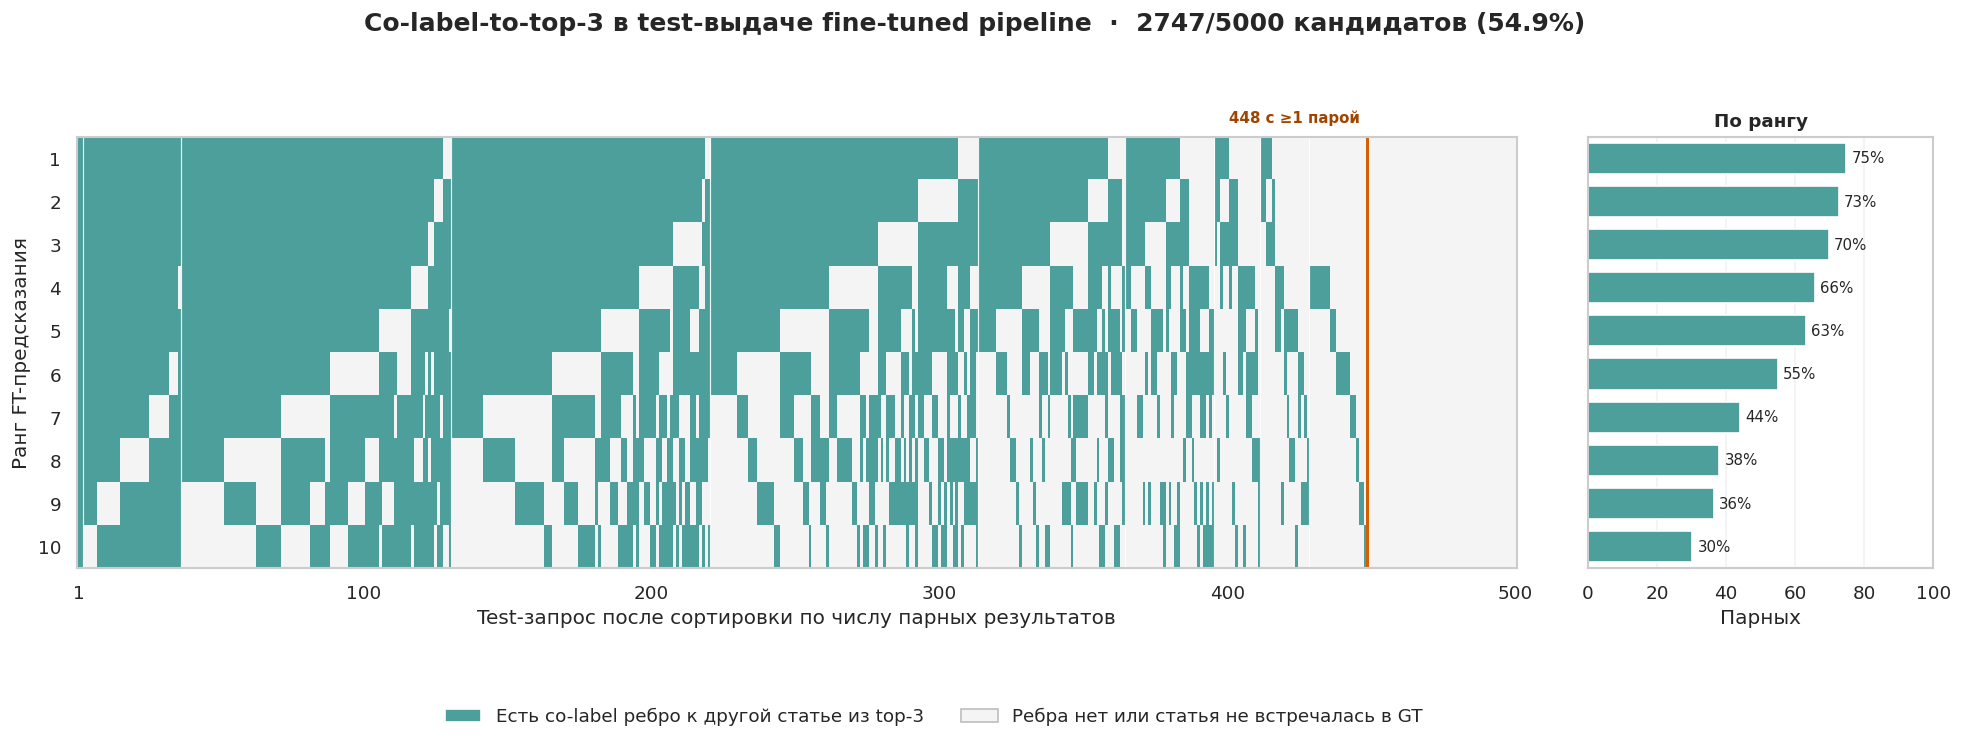

Хотя бы одна co-label-пара найдена у 448/500 test-запросов (89.6%).


In [11]:
def paired_with_top_k(predicted: list[int], graph: nx.Graph, k: int = 3) -> list[int]:
    """1, если кандидат имеет co-label ребро с другим кандидатом из top-k."""
    leaders = predicted[:k]
    return [
        int(any(other != aid and graph.has_edge(aid, other) for other in leaders))
        for aid in predicted
    ]

# Для feature engineering не используем 100 holdout-запросов даже как источник рёбер.
co_label_graph_dev = nx.Graph()
for qid in dev_ids:
    co_label_graph_dev.add_nodes_from(gt[qid])
    co_label_graph_dev.add_edges_from(combinations(sorted(gt[qid]), 2))

ft_test_query_ids = list(ft_test_rank)
paired_flags = np.array([
    paired_with_top_k(ft_test_rank[qid], co_label_graph_dev, k=3)
    for qid in ft_test_query_ids
], dtype=np.uint8)
paired_per_query = paired_flags.sum(axis=1)

# Сначала запросы с большим числом пар, затем — с парой на более высоком ранге.
column_order = sorted(
    range(len(ft_test_query_ids)),
    key=lambda index: (int(paired_per_query[index]), *paired_flags[index].tolist()),
    reverse=True,
)
paired_for_plot = paired_flags[column_order].T
ordered_pair_counts = paired_per_query[column_order]
paired_rate_by_rank = 100 * paired_flags.mean(axis=0)
queries_with_pair = int((paired_per_query > 0).sum())

pair_cmap = mpl.colors.ListedColormap(["#F4F4F4", "#4C9F9B"])
pair_norm = mpl.colors.BoundaryNorm([-0.5, 0.5, 1.5], pair_cmap.N)
fig, (ax_matrix, ax_rate) = plt.subplots(
    1, 2, figsize=(17, 5.8), sharey=True,
    gridspec_kw={"width_ratios": [7.5, 1.8], "wspace": 0.08},
)

ax_matrix.imshow(
    paired_for_plot, aspect="auto", interpolation="nearest",
    cmap=pair_cmap, norm=pair_norm,
)
# Границы групп с одинаковым числом парных результатов в top-10.
group_boundaries = np.flatnonzero(np.diff(ordered_pair_counts)) + 0.5
for boundary in group_boundaries:
    ax_matrix.axvline(boundary, color="white", linewidth=0.7, alpha=0.9)
if queries_with_pair < len(ft_test_query_ids):
    ax_matrix.axvline(queries_with_pair - 0.5, color="#D55E00", linewidth=1.8)
    ax_matrix.text(
        queries_with_pair - 3, -0.75, f"{queries_with_pair} с ≥1 парой",
        ha="right", va="bottom", color="#A04400", fontsize=9, fontweight="bold",
    )
ax_matrix.set_yticks(np.arange(10), np.arange(1, 11))
tick_positions = np.linspace(0, len(ft_test_query_ids) - 1, 6, dtype=int)
ax_matrix.set_xticks(tick_positions, tick_positions + 1)
ax_matrix.set_xlabel("Test-запрос после сортировки по числу парных результатов")
ax_matrix.set_ylabel("Ранг FT-предсказания")
ax_matrix.grid(False)

rank_positions = np.arange(10)
bars = ax_rate.barh(rank_positions, paired_rate_by_rank, color="#4C9F9B", height=0.72)
for bar, value in zip(bars, paired_rate_by_rank):
    ax_rate.text(value + 1.5, bar.get_y() + bar.get_height() / 2, f"{value:.0f}%", va="center", fontsize=9)
ax_rate.set_xlim(0, 100)
ax_rate.set_xlabel("Парных")
ax_rate.set_title("По рангу", fontsize=11)
ax_rate.grid(axis="x", alpha=0.25)
ax_rate.grid(axis="y", visible=False)

fig.legend(
    handles=[
        Patch(facecolor="#4C9F9B", label="Есть co-label ребро к другой статье из top-3"),
        Patch(facecolor="#F4F4F4", edgecolor="#BDBDBD", label="Ребра нет или статья не встречалась в GT"),
    ],
    loc="lower center", bbox_to_anchor=(0.48, -0.03), ncol=2, frameon=False,
)
fig.suptitle(
    "Co-label-to-top-3 в test-выдаче fine-tuned pipeline"
    f"  ·  {paired_flags.sum()}/{paired_flags.size} кандидатов ({paired_flags.mean():.1%})",
    fontsize=15, fontweight="bold", y=1.02,
)
fig.subplots_adjust(left=0.06, right=0.97, top=0.84, bottom=0.22, wspace=0.08)
plt.show()

print(
    f"Хотя бы одна co-label-пара найдена у {queries_with_pair}/{len(ft_test_query_ids)} "
    f"test-запросов ({queries_with_pair / len(ft_test_query_ids):.1%})."
)

### Из наблюдения — в признак (реализовано в пайплайне)

Рисунок выше — верхняя граница пользы признака: у 54.9% test-кандидатов есть co-label пара в топ-3, то есть признаку есть где срабатывать. В пайплайне это оформлено в `src/support_search/features/graphs.py` (стадия blend, конфиг `ranking.graph_features`):

- `co_top_p` — max по топ-3 лидерам условная вероятность P(кандидат в GT | лидер в GT) = W(пара)/freq(лидера). Нормировка — прямое следствие матрицы §3: она отличает эксклюзивные связки (пара `2665–4214` встречается в 7 из ~8 запросов своего якоря) от хабовых совместностей (`4219–2646`: 45 из ~200). Сырой вес `co_top_w` = log1p(W) оставлен ablation-режимом `co_weight: raw` — он даёт OOF на 0.0014 ниже;
- `link_top`, `sim_top` — те же связи по HTML-ссылкам и dense-косинусу: не зависят от разметки и покрывают все 793 статьи (fallback для белых квадратов — статей вне 79 размеченных);
- `gt_freq` — log1p(частота статьи как GT): явный прайор популярности вместо неявного смещения FT;
- `co_x_margin` — co-фича × нормированный отрыв топ-1 от топ-2: поднимать пару к лидеру стоит тем сильнее, чем увереннее сам лидер.

Протокол без утечки — ровно тот, что описан здесь: граф фолда строится только по его train-разметке, у train-строк собственный вклад запроса вычитается (leave-one-out — и из веса пары, и из частоты якоря), для test граф берётся из всей dev-разметки (у test-запросов своих меток нет). Результаты OOF — в §10.

___

## 9. Истинные FT-попадания: одиночный или парный ответ

Теперь используем ground truth, но только для **400 dev-запросов с честными OOF-предсказаниями**. Клетка — статья на соответствующем ранге fine-tuned blend:

- синий — статья действительно релевантна, и у запроса ровно одна GT-статья;
- оранжевый — статья действительно релевантна, и у запроса две или более GT-статьи;
- светло-серый — предсказанная статья не входит в GT запроса.

Сто holdout-запросов вынесены в отдельный заштрихованный блок. Их сохранённые blend-строки намеренно пусты, поэтому мы не строим для них фиктивные ранги, не сортируем по качеству и не включаем в правую статистику.

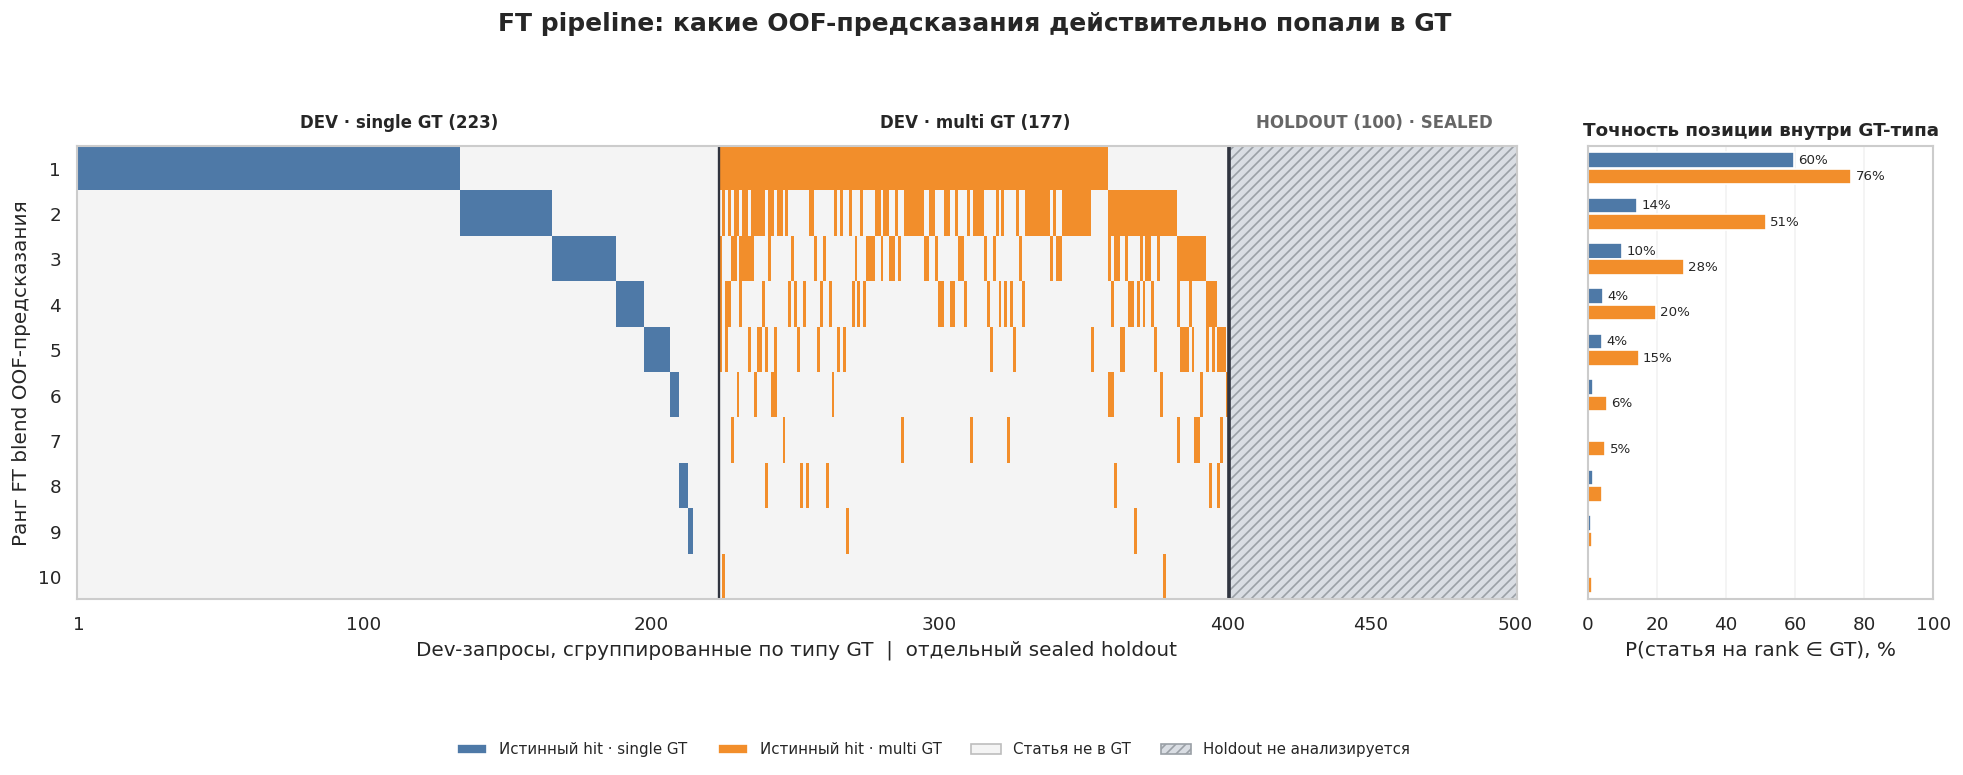

Dev OOF: 223 single-GT и 177 multi-GT запросов; хотя бы один hit@10: 96.0% и 100.0%. Holdout: 100 запросов, исключён из расчёта.


In [12]:
ft_blend_cal = load_score_matrix(
    SOLUTION / "artifacts_rr_bge_ft_labeled/scores/blend/calibration.npz"
)
dev_query_ids = sorted(dev_ids)
holdout_query_ids = sorted(int(qid) for qid in split_data["holdout"])
cal_row_of = {int(qid): row for row, qid in enumerate(ft_blend_cal["query_ids"])}

# Защита от случайного анализа: сохранённые holdout-строки обязаны быть пустыми.
holdout_rows = [cal_row_of[qid] for qid in holdout_query_ids]
assert np.all(ft_blend_cal["scores"][holdout_rows] == 0), (
    "Holdout неожиданно содержит скоры: остановитесь и проверьте протокол"
)

dev_ft_blend_rank: dict[int, list[int]] = {}
for qid in dev_query_ids:
    row = ft_blend_cal["scores"][cal_row_of[qid]]
    order = np.lexsort((ft_blend_cal["article_ids"], -row))[:10]
    dev_ft_blend_rank[qid] = ft_blend_cal["article_ids"][order].tolist()

def hit_sort_key(qid: int) -> tuple[int, int, int]:
    hit_flags = [aid in gt[qid] for aid in dev_ft_blend_rank[qid]]
    first_hit = next((rank for rank, hit in enumerate(hit_flags) if hit), 10)
    return first_hit, -sum(hit_flags), qid

single_dev = sorted((qid for qid in dev_query_ids if len(gt[qid]) == 1), key=hit_sort_key)
paired_dev = sorted((qid for qid in dev_query_ids if len(gt[qid]) > 1), key=hit_sort_key)
ordered_dev = single_dev + paired_dev
n_single, n_dev, n_holdout = len(single_dev), len(ordered_dev), len(holdout_query_ids)

# 0 = ошибка, 1 = истинный single-hit, 2 = истинный paired-hit, 3 = sealed holdout.
hit_type_matrix = np.full((10, n_dev + n_holdout), 3, dtype=np.uint8)
for column, qid in enumerate(ordered_dev):
    true_hit_code = 1 if len(gt[qid]) == 1 else 2
    hit_type_matrix[:, column] = [
        true_hit_code if aid in gt[qid] else 0
        for aid in dev_ft_blend_rank[qid]
    ]

single_rate_by_rank = 100 * (hit_type_matrix[:, :n_single] == 1).mean(axis=1)
paired_rate_by_rank = 100 * (hit_type_matrix[:, n_single:n_dev] == 2).mean(axis=1)

hit_cmap = mpl.colors.ListedColormap(["#F4F4F4", "#4E79A7", "#F28E2B", "#D9DDE3"])
hit_norm = mpl.colors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], hit_cmap.N)
fig, (ax_matrix, ax_rate) = plt.subplots(
    1, 2, figsize=(17, 6.2), sharey=True,
    gridspec_kw={"width_ratios": [7.5, 1.8], "wspace": 0.08},
)
ax_matrix.imshow(hit_type_matrix, aspect="auto", interpolation="nearest", cmap=hit_cmap, norm=hit_norm)
ax_matrix.axvline(n_single - 0.5, color="#30343F", linewidth=1.4)
ax_matrix.axvline(n_dev - 0.5, color="#30343F", linewidth=2.2)
ax_matrix.add_patch(Rectangle(
    (n_dev - 0.5, -0.5), n_holdout, 10, facecolor="none",
    hatch="////", edgecolor="#9AA0A6", linewidth=0.0,
))
ax_matrix.text(n_single / 2, -0.9, f"DEV · single GT ({n_single})", ha="center", fontweight="bold", clip_on=False)
ax_matrix.text((n_single + n_dev) / 2, -0.9, f"DEV · multi GT ({n_dev - n_single})", ha="center", fontweight="bold", clip_on=False)
ax_matrix.text(n_dev + n_holdout / 2, -0.9, f"HOLDOUT ({n_holdout}) · SEALED", ha="center", color="#666666", fontweight="bold", clip_on=False)
ax_matrix.set_yticks(np.arange(10), np.arange(1, 11))
ax_matrix.set_xticks([0, 99, 199, 299, 399, 449, 499], [1, 100, 200, 300, 400, 450, 500])
ax_matrix.set_xlabel("Dev-запросы, сгруппированные по типу GT  |  отдельный sealed holdout")
ax_matrix.set_ylabel("Ранг FT blend OOF-предсказания")
ax_matrix.grid(False)

rank_positions = np.arange(10)
bar_height = 0.34
single_bars = ax_rate.barh(rank_positions - 0.18, single_rate_by_rank, height=bar_height, color="#4E79A7")
paired_bars = ax_rate.barh(rank_positions + 0.18, paired_rate_by_rank, height=bar_height, color="#F28E2B")
for bars in (single_bars, paired_bars):
    for bar in bars:
        value = bar.get_width()
        if value >= 4:
            ax_rate.text(value + 1.2, bar.get_y() + bar.get_height() / 2, f"{value:.0f}%", va="center", fontsize=8)
ax_rate.set_xlim(0, 100)
ax_rate.set_xlabel("P(статья на rank ∈ GT), %")
ax_rate.set_title("Точность позиции внутри GT-типа", fontsize=11)
ax_rate.grid(axis="x", alpha=0.25)
ax_rate.grid(axis="y", visible=False)

fig.legend(
    handles=[
        Patch(facecolor="#4E79A7", label="Истинный hit · single GT"),
        Patch(facecolor="#F28E2B", label="Истинный hit · multi GT"),
        Patch(facecolor="#F4F4F4", edgecolor="#BDBDBD", label="Статья не в GT"),
        Patch(facecolor="#D9DDE3", edgecolor="#9AA0A6", hatch="////", label="Holdout не анализируется"),
    ],
    loc="lower center", bbox_to_anchor=(0.48, -0.01), ncol=4, frameon=False, fontsize=9,
)
fig.suptitle("FT pipeline: какие OOF-предсказания действительно попали в GT", fontsize=15, fontweight="bold", y=1.01)
fig.subplots_adjust(left=0.06, right=0.97, top=0.83, bottom=0.22, wspace=0.08)
plt.show()

single_hit_at_10 = np.mean([any(aid in gt[qid] for aid in dev_ft_blend_rank[qid]) for qid in single_dev])
paired_hit_at_10 = np.mean([any(aid in gt[qid] for aid in dev_ft_blend_rank[qid]) for qid in paired_dev])
print(
    f"Dev OOF: {n_single} single-GT и {n_dev - n_single} multi-GT запросов; "
    f"хотя бы один hit@10: {single_hit_at_10:.1%} и {paired_hit_at_10:.1%}. "
    f"Holdout: {n_holdout} запросов, исключён из расчёта."
)

### Что проверяет этот рисунок

- Метка single/multi — свойство запроса (число его GT-статей), известное только из разметки. Это **target-срез для оценки**, а не признак: на test её нет и в модель она не подаётся.
- На multi-GT запросах попадания плотнее на всех рангах (76% vs 60% на топ-1, 51% vs 14% на топ-2): «вторая статья пары» систематически присутствует в топе — именно эту структуру и монетизирует вычислимый без GT `co_top_w` из §8.
- Holdout присутствует только как заштрихованная зона протокола: его строки в сохранённой blend-матрице пусты (см. assert в коде), все решения о признаках принимает fold-wise OOF на 400 dev-запросах.

---

## 10. Итог: из диагностики в пайплайн

Диагностика превратилась в код и цифры (стадия blend, эксперимент `rerank_ft_lemma_graph.yaml`; всюду честный OOF на 400 dev, 5 фолдов, реранкер и ретрив зафиксированы):

| Финальная голова | OOF MAP@10 | Комментарий |
|---|---|---|
| mini-LTR, 8 базовых признаков | 0.7375 | предыдущий финал |
| + граф-фичи, сырой co-вес log1p(W) | 0.7470 | p = 0.051 vs базовый LR (permutation) |
| + условная нормировка P(кандидат\|якорь) — **финал** | **0.7484** | ловит эксклюзивные пары §3; p = 0.068 vs базовый LR |
| listwise MLP [16], wd = 0.03, те же фичи | 0.7484 | сид 42, p ≈ 1.0 vs LR; по сидам 0.736–0.750, ансамбль сидов ниже LR |

Что подтвердилось, а что нет:

1. **Co-label-связность — рабочий сигнал, и лучше в условной форме.** Сырой вес путает «часто вместе» с «только вместе»; P(кандидат | якорь) поднимает эксклюзивные связки («инструкция + правила») и добавляет ещё +0.0014. Нагрузка в LR распределена по связке `co_top_p` + `co_x_margin` + `gt_freq` — коэффициенты коррелированных признаков по отдельности не интерпретируются, работает пучок.
2. **Прайор популярности** легален и помогает (`gt_freq`): явная фича с отдельной ablation-строкой честнее неявного смещения дообученного реранкера.
3. **HTML-ссылки и dense-похожесть как ранжирующие фичи пусты** (веса ≈ 0): лидеры топ-3 почти всегда из 79 размеченных статей, и там co-label уже покрывает их сигнал. Их роль остаётся защитной — фильтр false negatives при майнинге hard negatives.
4. **«Влить варианс» в голову не сработало.** MLP шире `[16]` или дольше 300 эпох деградирует вплоть до 0.35 — классическое переобучение на 320 обучающих запросах фолда. Лучший крошечный вариант на финальных фичах сравнялся с LR (0.7484, p ≈ 1.0), но результат пляшет от сида (0.736–0.750), а детерминированный ансамбль сидов — ниже LR. Финальная голова — LR: воспроизводимая, интерпретируемая, не хуже.

Траектория dev OOF финального blend: 0.7333 → 0.7378 (лемматизация лексики) → 0.7470 (граф-фичи) → **0.7484** (условная нормировка co-label).

___

## 11. Дисперсия пяти FT-моделей и эффект усреднения

Здесь разделены два разных вопроса, которые легко случайно смешать:

1. **Fold stability:** каждая из пяти моделей оценивается на своём честном OOF-фолде. Эти графики доступны сразу, но смешивают сложность конкретного фолда и качество конкретной модели.
2. **Чистый ensemble test:** все пять моделей оцениваются на одних и тех же 100 holdout-запросах, которых не видела ни одна модель. Только этот эксперимент отвечает, помогает ли усреднение logits по сравнению с одной моделью.

> Оценивать все пять моделей на одном обычном dev-фолде нельзя: четыре из них видели его ответы при обучении. Общий holdout здесь используется как измерительный стенд, а не как источник настройки модели.

,fold,stage,n,MAP@10,low,high,Recall@10
0,0,FT reranker,82,0.6855,0.6128,0.7555,94.5%
2,1,FT reranker,80,0.6815,0.6063,0.7564,93.3%
4,2,FT reranker,80,0.7031,0.6292,0.7732,94.6%
6,3,FT reranker,79,0.7006,0.6251,0.7720,93.7%
8,4,FT reranker,79,0.6766,0.6091,0.7432,95.6%
1,0,Final blend,82,0.7609,0.6991,0.8185,96.3%
3,1,Final blend,80,0.7637,0.6952,0.8305,97.3%
5,2,Final blend,80,0.7617,0.6952,0.8250,97.5%
7,3,Final blend,79,0.7730,0.7076,0.8352,94.9%
9,4,Final blend,79,0.7661,0.6982,0.8319,95.8%


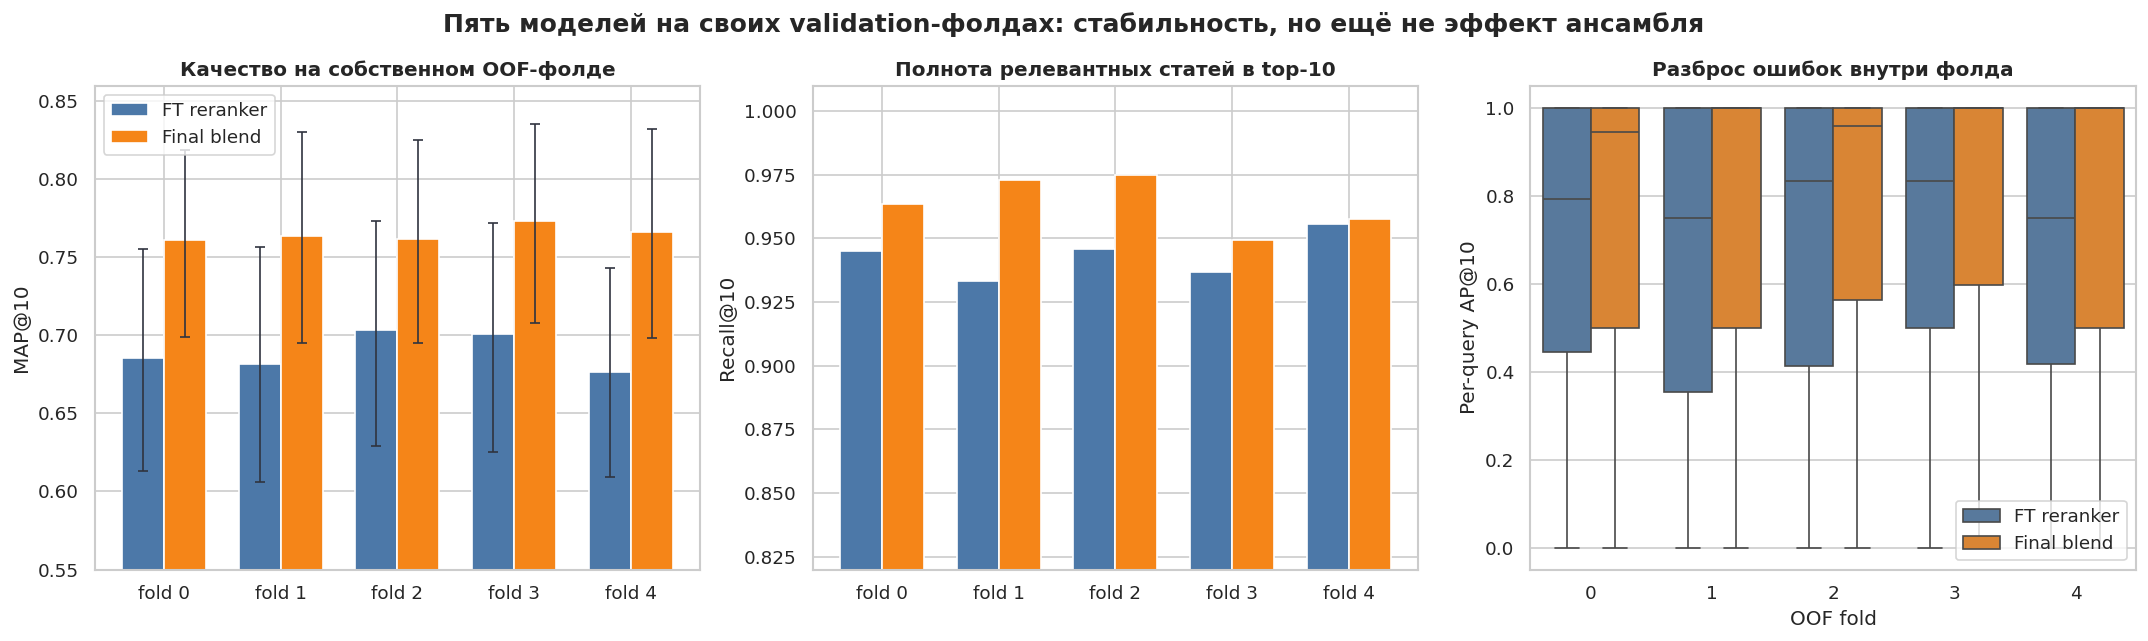

In [13]:
# Доступно без нового inference: каждая модель предсказывает только свой OOF-фолд.
ep3_artifact = SOLUTION / "artifacts_rr_ft_k50_ep3"
ep3_split = json.loads((ep3_artifact / "splits/folds.json").read_text())
ep3_dev = sorted(int(qid) for qid in ep3_split["dev"])
ep3_fold_of = {int(qid): int(fold) for qid, fold in ep3_split["fold_of"].items()}
ep3_rr = load_score_matrix(ep3_artifact / "scores/reranker/calibration.npz")
ep3_blend = load_score_matrix(ep3_artifact / "scores/blend/calibration.npz")
ep3_rr_rank = rankings(ep3_rr, 50)
ep3_blend_rank = rankings(ep3_blend, 50)

def recall_at_10(predicted: list[int], relevant: set[int]) -> float:
    return len(set(predicted[:10]) & relevant) / len(relevant) if relevant else 0.0

def mean_ci(values, seed: int) -> tuple[float, float, float]:
    values = np.asarray(values, dtype=float)
    local_rng = np.random.default_rng(seed)
    sampled = values[local_rng.integers(0, len(values), size=(10_000, len(values)))]
    return float(values.mean()), *np.quantile(sampled.mean(axis=1), [0.025, 0.975])

fold_query_rows = []
for qid in ep3_dev:
    fold_query_rows.extend([
        {"query_id": qid, "fold": ep3_fold_of[qid], "stage": "FT reranker",
         "ap@10": ap_at_10(ep3_rr_rank[qid], gt[qid]),
         "recall@10": recall_at_10(ep3_rr_rank[qid], gt[qid])},
        {"query_id": qid, "fold": ep3_fold_of[qid], "stage": "Final blend",
         "ap@10": ap_at_10(ep3_blend_rank[qid], gt[qid]),
         "recall@10": recall_at_10(ep3_blend_rank[qid], gt[qid])},
    ])
fold_query_df = pd.DataFrame(fold_query_rows)

fold_metric_rows = []
for (fold, stage), group in fold_query_df.groupby(["fold", "stage"]):
    mean, low, high = mean_ci(group["ap@10"], seed=420 + int(fold) + (100 if stage == "Final blend" else 0))
    fold_metric_rows.append({
        "fold": int(fold), "stage": stage, "n": len(group),
        "MAP@10": mean, "low": low, "high": high,
        "Recall@10": group["recall@10"].mean(),
    })
fold_metric_df = pd.DataFrame(fold_metric_rows)
display(fold_metric_df.sort_values(["stage", "fold"]).style.format({
    "MAP@10": "{:.4f}", "low": "{:.4f}", "high": "{:.4f}", "Recall@10": "{:.1%}",
}))

fig, axes = plt.subplots(1, 3, figsize=(18, 5.4))
folds = np.arange(5)
width = 0.36
stage_style = {"FT reranker": ("#4C78A8", -width / 2), "Final blend": ("#F58518", width / 2)}
for stage, (color, offset) in stage_style.items():
    part = fold_metric_df[fold_metric_df["stage"] == stage].sort_values("fold")
    axes[0].bar(folds + offset, part["MAP@10"], width, color=color, label=stage)
    axes[0].errorbar(
        folds + offset, part["MAP@10"],
        yerr=[part["MAP@10"] - part["low"], part["high"] - part["MAP@10"]],
        fmt="none", ecolor="#30343F", capsize=3, linewidth=1,
    )
    axes[1].bar(folds + offset, part["Recall@10"], width, color=color, label=stage)
axes[0].set_xticks(folds, [f"fold {fold}" for fold in folds])
axes[0].set_ylabel("MAP@10")
axes[0].set_title("Качество на собственном OOF-фолде")
axes[0].set_ylim(0.55, 0.86)
axes[0].legend()
axes[1].set_xticks(folds, [f"fold {fold}" for fold in folds])
axes[1].set_ylabel("Recall@10")
axes[1].set_title("Полнота релевантных статей в top-10")
axes[1].set_ylim(0.82, 1.01)

sns.boxplot(data=fold_query_df, x="fold", y="ap@10", hue="stage",
            palette={"FT reranker": "#4C78A8", "Final blend": "#F58518"}, ax=axes[2])
axes[2].set_xlabel("OOF fold")
axes[2].set_ylabel("Per-query AP@10")
axes[2].set_title("Разброс ошибок внутри фолда")
axes[2].legend(title=None, loc="lower right")
fig.suptitle("Пять моделей на своих validation-фолдах: стабильность, но ещё не эффект ансамбля",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

### Общий holdout: чистое измерение variance reduction

Для следующего рисунка нужны отдельные, **не усреднённые** предсказания пяти моделей `artifacts_rr_ft_k50_ep3/models/reranker_ft/fold_0…4` на одних и тех же 100 holdout-запросах. Сейчас pipeline сохраняет только их среднее для test, поэтому эти данные нужно один раз получить внешним GPU-runner после завершения обучения.

Ожидаемый файл: `solution/experiments/generated/holdout_fold_scores_ep3.npz`:

| массив | shape | смысл |
|---|---:|---|
| `query_ids` | `[100]` | одинаковый порядок holdout-запросов |
| `article_ids` | `[793]` | порядок статей |
| `scores` | `[5, 100, 793]` | raw logits каждой fold-модели |

Кандидаты и passages должны быть одинаковы для всех пяти моделей. Снаружи top-50 допустим общий sentinel. Ноутбук GPU не запускает: если файла нет, следующая ячейка покажет контракт и завершится без ошибки.

,model,MAP@10,Recall@10
0,fold 0,0.6837,91.7%
1,fold 1,0.6517,90.7%
2,fold 2,0.6453,90.8%
3,fold 3,0.6728,91.7%
4,fold 4,0.6619,90.8%
5,raw mean-5,0.6865,91.3%
6,z-mean-5,0.6854,90.8%
7,RR-mean-5,0.6932,90.3%


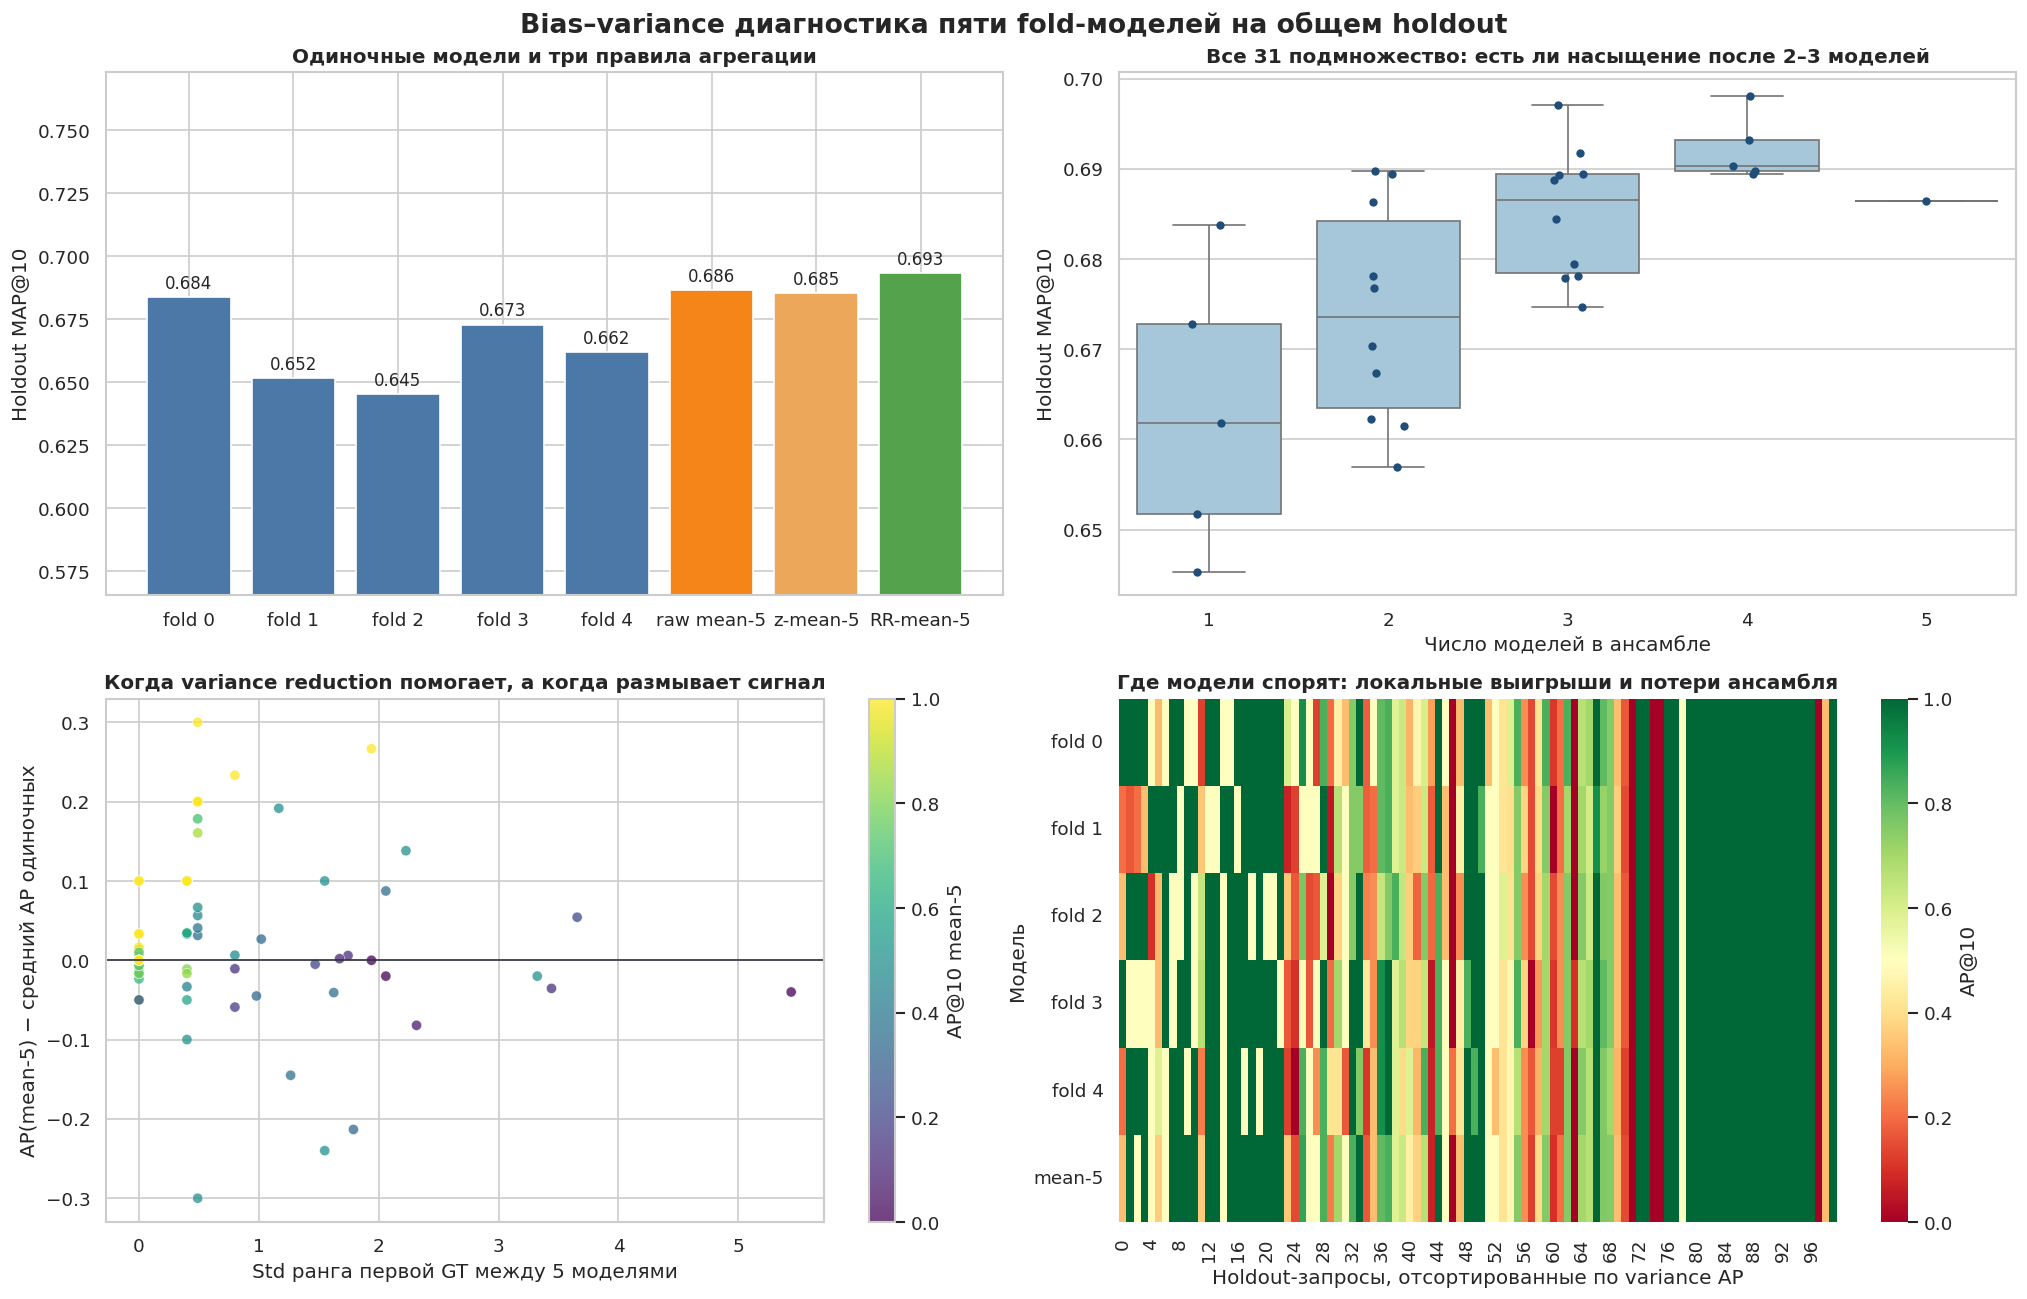

In [14]:
ensemble_score_path = SOLUTION / "experiments/generated/holdout_fold_scores_ep3.npz"

if not ensemble_score_path.exists():
    display(pd.DataFrame([
        {"status": "ожидает GPU inference", "path": str(ensemble_score_path),
         "нужно": "query_ids[100], article_ids[793], scores[5,100,793]"}
    ]))
else:
    with np.load(ensemble_score_path, allow_pickle=False) as data:
        common_qids = data["query_ids"].astype(np.int64)
        common_article_ids = data["article_ids"].astype(np.int64)
        fold_scores = data["scores"].astype(np.float32)
    assert fold_scores.shape == (5, len(common_qids), len(common_article_ids))
    assert set(common_qids) == set(holdout_query_ids)

    def metrics_from_scores(score_rows: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
        aps, recalls, first_ranks = [], [], []
        for qid, row in zip(common_qids, score_rows):
            order = np.lexsort((common_article_ids, -row))
            predicted = common_article_ids[order].tolist()
            relevant = gt[int(qid)]
            aps.append(ap_at_10(predicted, relevant))
            recalls.append(recall_at_10(predicted, relevant))
            first_ranks.append(next((rank for rank, aid in enumerate(predicted[:50], 1) if aid in relevant), 51))
        return np.asarray(aps), np.asarray(recalls), np.asarray(first_ranks)

    individual_ap, individual_recall, individual_first = [], [], []
    for fold in range(5):
        ap_values, recall_values, first_values = metrics_from_scores(fold_scores[fold])
        individual_ap.append(ap_values)
        individual_recall.append(recall_values)
        individual_first.append(first_values)
    individual_ap = np.stack(individual_ap)
    individual_recall = np.stack(individual_recall)
    individual_first = np.stack(individual_first)

    # Две агрегации, устойчивые к разному масштабу logits между fold-моделями.
    z_scores = np.full_like(fold_scores, -1.0e30)
    reciprocal_rank_scores = np.zeros_like(fold_scores)
    for fold in range(5):
        for query_index in range(len(common_qids)):
            candidate_mask = fold_scores[fold, query_index] > -1.0e20
            candidate_columns = np.flatnonzero(candidate_mask)
            values = fold_scores[fold, query_index, candidate_mask]
            z_scores[fold, query_index, candidate_mask] = (values - values.mean()) / (values.std() + 1.0e-6)
            order = candidate_columns[np.lexsort((
                common_article_ids[candidate_columns], -fold_scores[fold, query_index, candidate_columns]
            ))]
            reciprocal_rank_scores[fold, query_index, order] = 1.0 / np.arange(1, len(order) + 1)
    zmean_ap, zmean_recall, _ = metrics_from_scores(z_scores.mean(axis=0))
    rrmean_ap, rrmean_recall, _ = metrics_from_scores(reciprocal_rank_scores.mean(axis=0))

    ensemble_rows = []
    subset_ap = {}
    for ensemble_size in range(1, 6):
        for subset in combinations(range(5), ensemble_size):
            ap_values, recall_values, first_values = metrics_from_scores(fold_scores[list(subset)].mean(axis=0))
            subset_ap[subset] = ap_values
            ensemble_rows.append({
                "size": ensemble_size, "models": "+".join(map(str, subset)),
                "MAP@10": ap_values.mean(), "Recall@10": recall_values.mean(),
                "mean first rank": first_values.mean(),
            })
    ensemble_df = pd.DataFrame(ensemble_rows)
    mean5_ap = subset_ap[tuple(range(5))]
    mean_individual_ap = individual_ap.mean(axis=0)
    ensemble_gain = mean5_ap - mean_individual_ap
    rank_disagreement = individual_first.std(axis=0)

    raw_mean_recall = metrics_from_scores(fold_scores.mean(axis=0))[1]
    model_summary = pd.DataFrame({
        "model": [f"fold {fold}" for fold in range(5)] + ["raw mean-5", "z-mean-5", "RR-mean-5"],
        "MAP@10": [*individual_ap.mean(axis=1), mean5_ap.mean(), zmean_ap.mean(), rrmean_ap.mean()],
        "Recall@10": [*individual_recall.mean(axis=1), raw_mean_recall.mean(),
                         zmean_recall.mean(), rrmean_recall.mean()],
    })
    display(model_summary.style.format({"MAP@10": "{:.4f}", "Recall@10": "{:.1%}"}))

    fig, axes = plt.subplots(2, 2, figsize=(17, 11))
    bar_colors = ["#4C78A8"] * 5 + ["#F58518", "#ECA75B", "#54A24B"]
    bars = axes[0, 0].bar(model_summary["model"], model_summary["MAP@10"], color=bar_colors)
    axes[0, 0].bar_label(bars, labels=[f"{value:.3f}" for value in model_summary["MAP@10"]], padding=3)
    axes[0, 0].set_ylabel("Holdout MAP@10")
    axes[0, 0].set_title("Одиночные модели и три правила агрегации")
    axes[0, 0].set_ylim(max(0, model_summary["MAP@10"].min() - 0.08),
                        min(1, model_summary["MAP@10"].max() + 0.08))

    sns.boxplot(data=ensemble_df, x="size", y="MAP@10", color="#9ECAE1", ax=axes[0, 1])
    sns.stripplot(data=ensemble_df, x="size", y="MAP@10", color="#1F4E79", size=5, ax=axes[0, 1])
    axes[0, 1].set_xlabel("Число моделей в ансамбле")
    axes[0, 1].set_ylabel("Holdout MAP@10")
    axes[0, 1].set_title("Все 31 подмножество: есть ли насыщение после 2–3 моделей")

    scatter = axes[1, 0].scatter(rank_disagreement, ensemble_gain, c=mean5_ap, cmap="viridis",
                                 s=38, alpha=0.75, edgecolor="white", linewidth=0.4)
    axes[1, 0].axhline(0, color="#30343F", linewidth=1)
    axes[1, 0].set_xlabel("Std ранга первой GT между 5 моделями")
    axes[1, 0].set_ylabel("AP(mean-5) − средний AP одиночных")
    axes[1, 0].set_title("Когда variance reduction помогает, а когда размывает сигнал")
    fig.colorbar(scatter, ax=axes[1, 0], label="AP@10 mean-5")

    query_order = np.argsort(individual_ap.var(axis=0))[::-1]
    heat = np.vstack([individual_ap, mean5_ap])[..., query_order]
    sns.heatmap(heat, cmap="RdYlGn", vmin=0, vmax=1, cbar_kws={"label": "AP@10"}, ax=axes[1, 1])
    axes[1, 1].set_yticklabels([f"fold {fold}" for fold in range(5)] + ["mean-5"], rotation=0)
    axes[1, 1].set_xlabel("Holdout-запросы, отсортированные по variance AP")
    axes[1, 1].set_ylabel("Модель")
    axes[1, 1].set_title("Где модели спорят: локальные выигрыши и потери ансамбля")

    fig.suptitle("Bias–variance диагностика пяти fold-моделей на общем holdout",
                 fontsize=16, fontweight="bold")
    plt.tight_layout()
    plt.show()

### Как принимать решение

- Левые верхние столбцы отвечают на прямой вопрос: лучше ли ансамбль средней и лучшей одиночной модели. `raw mean-5` усредняет logits, `z-mean-5` сначала выравнивает их масштаб внутри запроса, `RR-mean-5` усредняет обратные ранги и полностью игнорирует калибровку logits.
- Кривая по размеру ансамбля показывает compute/quality frontier. Если размер 2 уже достигает размера 5, три дополнительных inference-прохода не нужны.
- Нижний левый график — не классическое разложение squared-error bias–variance (для MAP оно не определено), а практически полезные proxy: disagreement рангов измеряет variance, а средняя ошибка одиночных моделей — bias/error. Точки ниже нуля означают, что усреднение размыло правильный уверенный сигнал.
- Heatmap отделяет равномерный маленький выигрыш от сценария, где ансамбль помогает нескольким запросам, но портит другие. Особенно важно отдельно перечитать запросы с singleton и unseen GT-статьями.

Финальный выбор нельзя делать по лучшей из 31 комбинации на holdout — это уже подбор по holdout. Корректные кандидаты: заранее фиксированная одиночная модель, mean первых двух моделей, raw mean-5 и отдельная single-model, обученная на всех dev-400.